In [1]:
from qeep import plot
from qeep import qeutils

import matplotlib.pyplot as plt

import numpy as np

import matplotlib.pyplot as plt

import yaml
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

from qeep import biases
from qeep import qeresults as qres
import jax
from jax import numpy as jnp


from qeep import fisher, forecast as fore

import os
os.environ['PATH'] = os.path.expanduser("~/texlive/2025/bin/aarch64-linux") + ":" + os.environ['PATH']

style_path = "paper.mplstyle"
plt.style.use(style_path)

In [2]:
configuration = '../../configs/abacus/config_desi_example_forecast_base.yaml'

X = fore.Forecaster(configuration)

Ks = X.Ks

### Simple Biases for $f_{NL}$

In [3]:

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)
QR = qres.QEResults(config, relative_path="../.")

#plt.loglog(Ks, QR.get_get_bispectrum_mixed_withB()("n"))
#plt.loglog(Ks, QR.get_get_bispectrum_mixed()("n"))


biases_dict = config["bias"]
number_density = config["number_density"]

nbar_A = number_density["nbar_A"]
nbar_B = number_density["nbar_B"]

b1A = biases_dict["b10_A"]
b1B = biases_dict["b10_B"]
e = 0

b2A, b2B = -0.3, -0.3
#b2A, b2B = biases.b2_fit(b1A), biases.b2_fit(b1B)
bs2A, bs2B = biases.bs2_coev(b1A), biases.bs2_coev(b1B)
bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 0, 0, 2, 1, 0, 0 
#bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 2, 1, 2, 1, 2, 1
fNL = 1

keys = ["g", "s", "t", "ga", "sa", "ta"]

v_fiducial = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])

from qeep import biases

configuration_fnl = '../../configs/abacus/config_desi_example_forecast_base_fnl.yaml'
X_fnl = fore.Forecaster(configuration_fnl)
with open(configuration_fnl, 'r') as f:
    config_fnl = yaml.safe_load(f)
QR_fnl = qres.QEResults(config_fnl, relative_path="../.")

keys_fnl = ["g", "s", "t", "ga", "sa", "ta", "c01", "c02", "phiphi", "c11a", "c01a", "c02a", "phiphia", "c11a"]
#keys_fnl = ["g", "s", "t", "ga", "sa", "ta", "phiphi", "phiphia"]
keys_symm = ["g", "s", "t", "phiphi", "c01", "c02", "c11"]

#keys_fnl = ["g", "s", "t", "ga", "sa", "ta"]
#keys_symm = ["g", "s", "t"]

def get_overall_bias(key_fnl, eps = 0, fNL = 0, return_partials = False):

    Cg_dict = {}
    for kk in keys_symm:
        Cg_symm = biases.get_symm_bias(f"{kk}", b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB, fNL = fNL, eps = eps)
        Cg_asymm = biases.get_asymm_bias(f"{kk}", b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB, fNL = fNL, eps = eps)
        Cg_dict[f"{kk}"] = Cg_symm
        Cg_dict[f"{kk}a"] = Cg_asymm
        
    Cg_effective = jnp.hstack([Cg_dict[kk] for kk in keys_fnl])

    normalization = QR_fnl.get_get_norm()(key_fnl)
    responses = qres.get_normalization_array(key_fnl, keys_fnl, X_fnl.Ks, QR_fnl.get_out_normalization_AB())
    
    partials = normalization * responses * Cg_effective[:, jnp.newaxis]
    
    overall_bias = fore.get_tot_bias_Cg(normalization,  Cg_effective, responses)
    if return_partials:
        return overall_bias, partials
    else:
        return overall_bias

(0.001, 0.05)

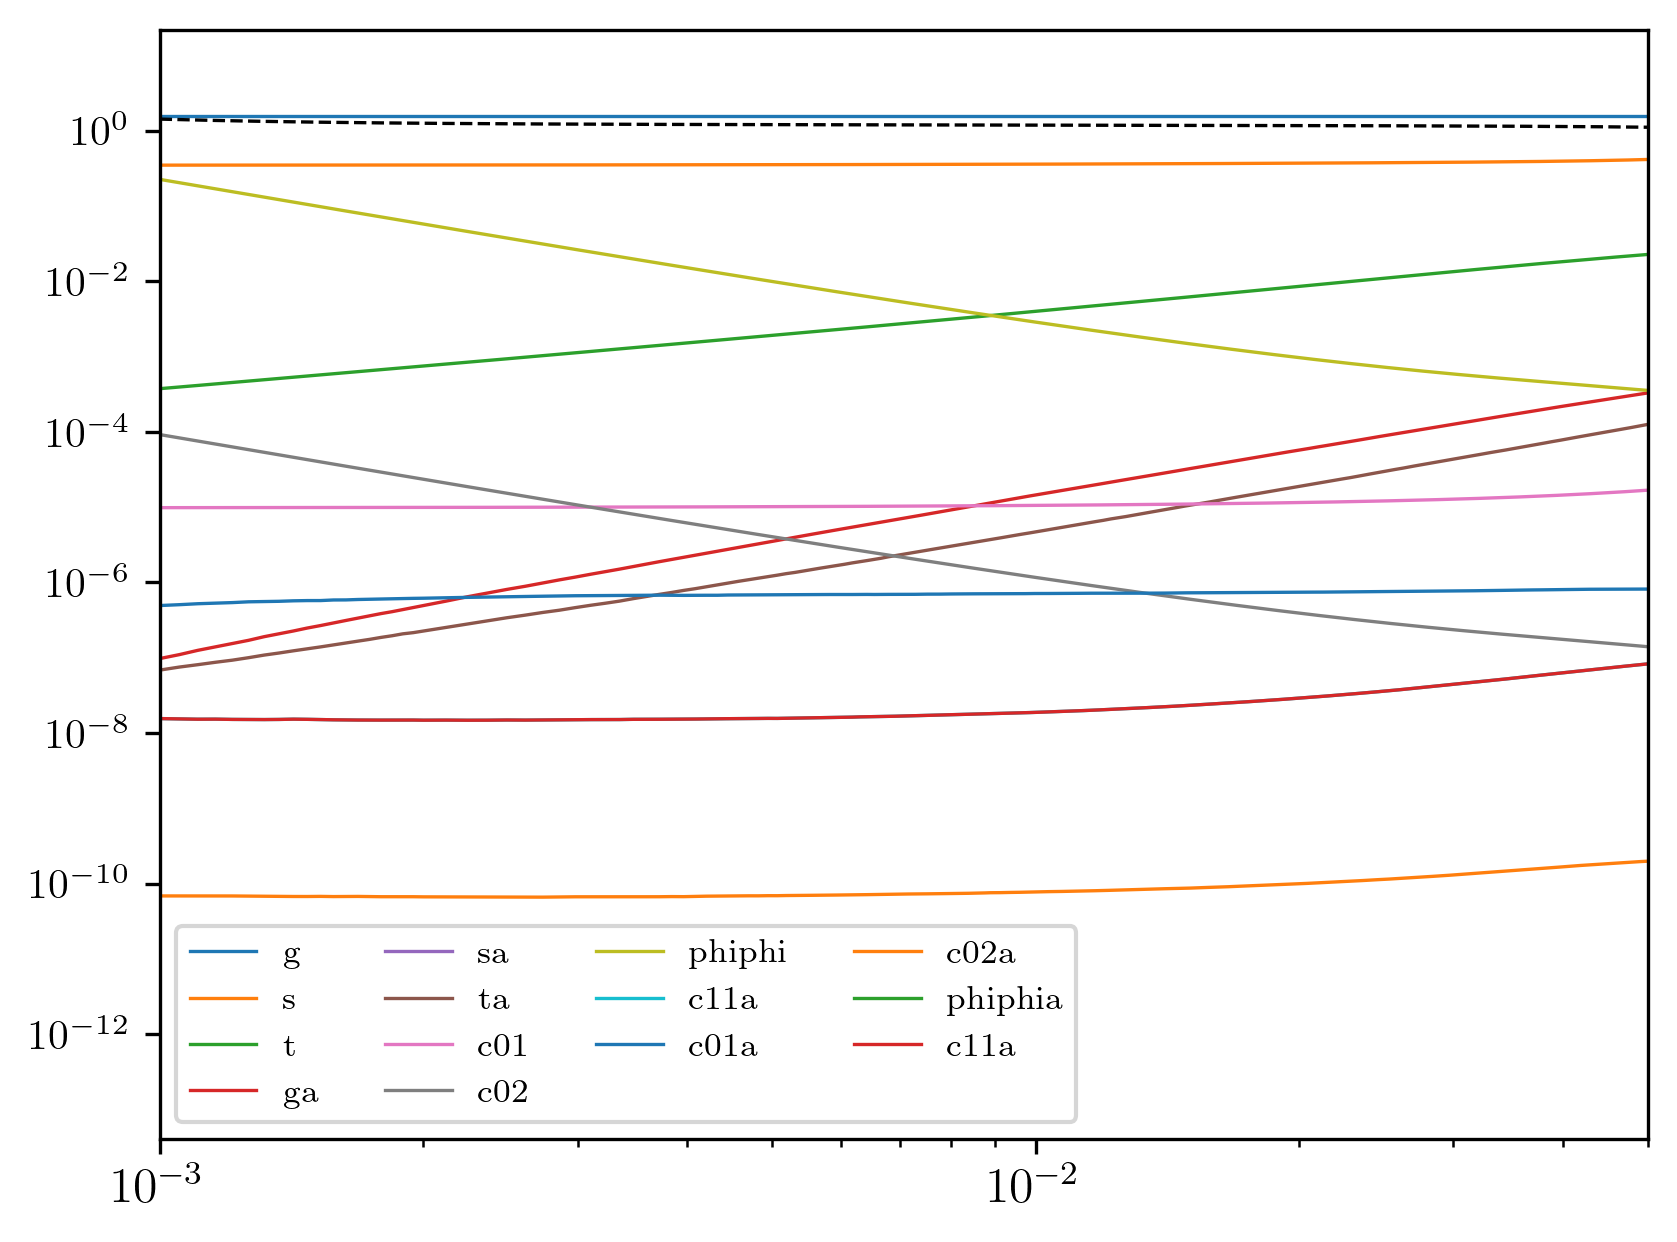

In [4]:
key_fnl = "g"

overall_bias, partials = get_overall_bias(key_fnl, eps = 0, fNL = 1, return_partials = True)
for i, k in enumerate(keys_fnl):
    #print(k, partials[i])
    plt.loglog(X_fnl.Ks, abs(partials[i]), label = k)
plt.loglog(X_fnl.Ks, abs(overall_bias), color = "black", ls = "--")
plt.legend(ncol = 4)
plt.xlim(1e-3, 5e-2)

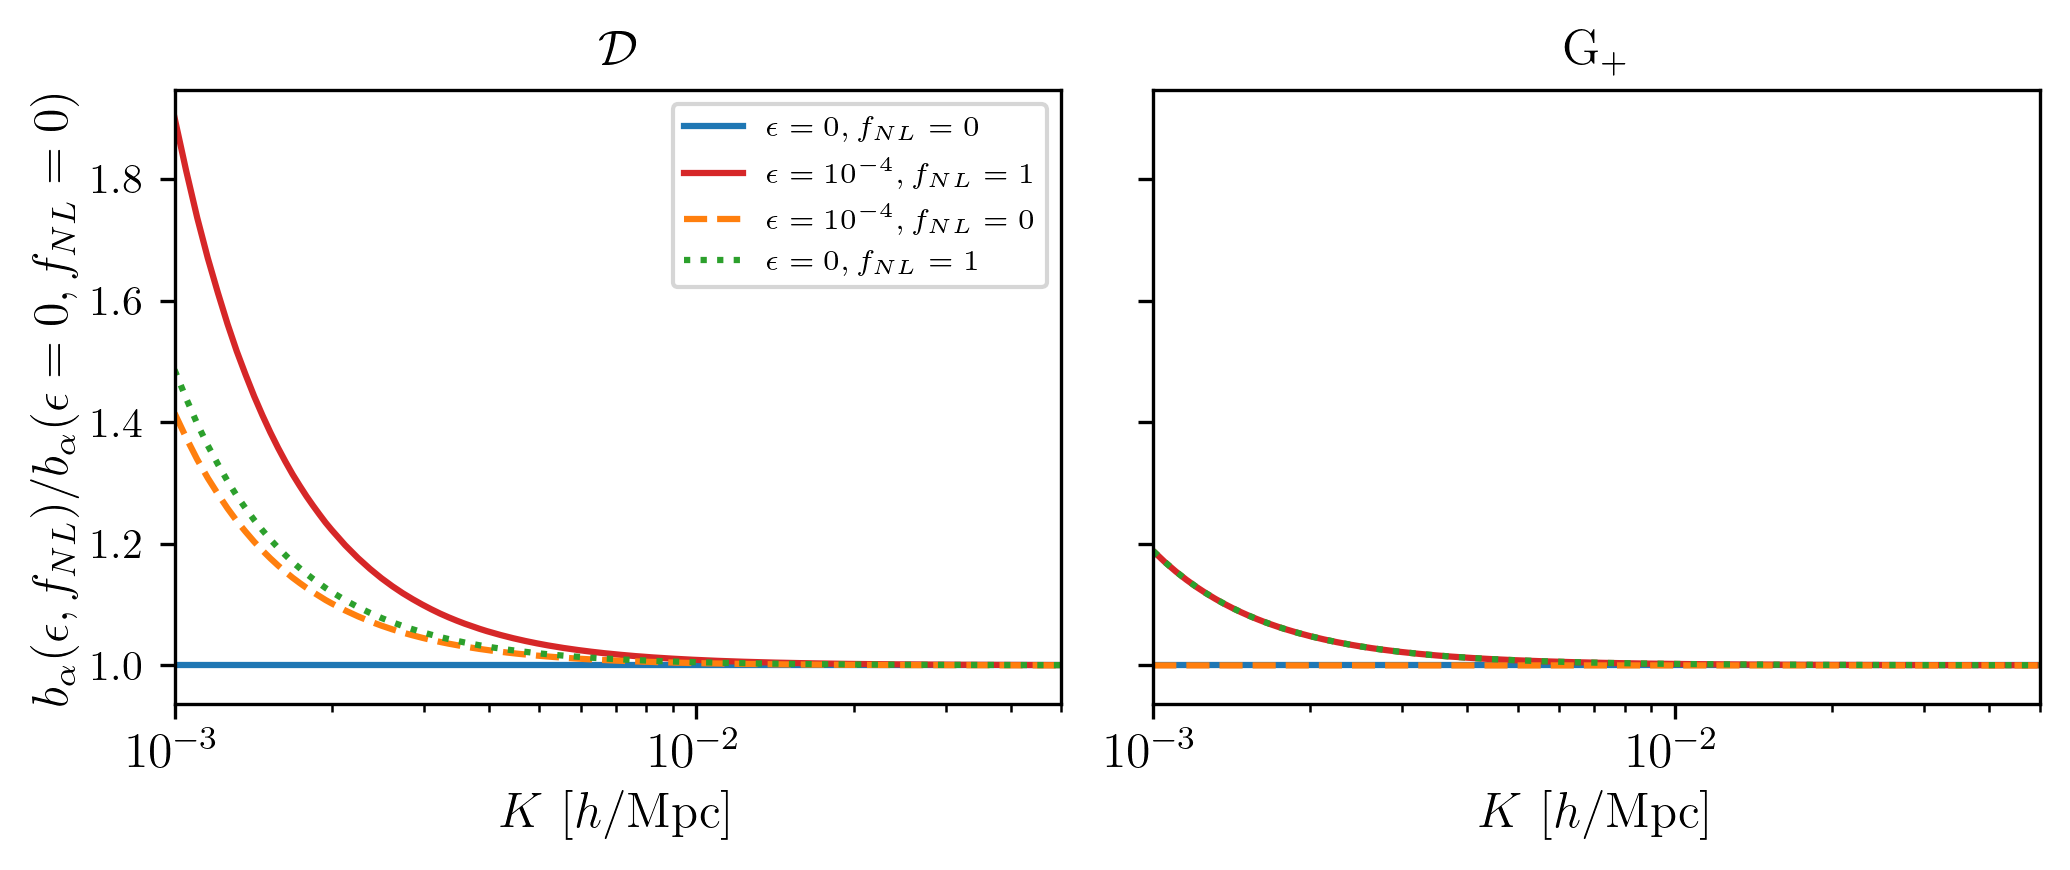

In [5]:
fig, axs = plt.subplots(1, 2, figsize = (7, 3), sharey = True)

for i, key_fnl in enumerate(["n", "g"]):
    fNL_val = 1
    eps_val = 1e-4

    lw = 1.5

    exponent = int(np.log10(eps_val))
    label = f"10^{{{exponent}}}"
    colors = plot.COLORBLIND_PALETTE_2

    base_ratio = get_overall_bias(key_fnl, eps = 0, fNL = 0)
    axs[i].loglog(X_fnl.Ks, abs((get_overall_bias(key_fnl, eps = 0, fNL = 0))/base_ratio), color = colors[0], label = r"$\epsilon = 0, f_{NL}=0$", lw = lw)
    axs[i].loglog(X_fnl.Ks, abs((get_overall_bias(key_fnl, eps = eps_val, fNL = fNL_val))/base_ratio), ls = "-", color = colors[3], label = rf"$\epsilon = {label}, f_{{NL}}={fNL_val}$", lw = lw)
    axs[i].loglog(X_fnl.Ks, abs((get_overall_bias(key_fnl, eps = eps_val, fNL = 0))/base_ratio), color = colors[1], ls = "--", label = rf"$\epsilon = {label}, f_{{NL}}=0$", lw = lw)
    axs[i].loglog(X_fnl.Ks, abs((get_overall_bias(key_fnl, eps = 0, fNL = fNL_val))/base_ratio), color = colors[2], ls = ":", label = rf"$\epsilon = 0, f_{{NL}}={fNL_val}$", lw = lw)

#plt.ylim(1)
    axs[i].set_yscale("linear")
    axs[i].set_xlim(1e-3, 5e-2)
    axs[i].set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=12)
    axs[i].set_title(plot.names[key_fnl])
    if i == 0:
        axs[i].legend(fontsize = 7)
        #axs[i].set_ylim(0.9, 2)
        axs[i].set_ylabel(r'$b_{\alpha}(\epsilon,f_{NL})/b_{\alpha}(\epsilon=0,f_{NL}=0)$', fontsize=12)
    else:
        1
        #axs[i].set_ylim(0.9, 2)
    #ax.set_ylabel(r'$\sigma_\epsilon(K)$', fontsize=12)

fig.tight_layout()
fig.savefig(f"figures/fnl_presence.pdf", dpi = 300, bbox_inches='tight')

### Let's make a simple test

In [6]:
configuration = '../../configs/abacus/config_desi_example_forecast_base.yaml'

X = fore.Forecaster(configuration)

Ks = X.Ks

In [7]:

with open(configuration, 'r') as f:
    config = yaml.safe_load(f)
QR = qres.QEResults(config, relative_path="../.")

#plt.loglog(Ks, QR.get_get_bispectrum_mixed_withB()("n"))
#plt.loglog(Ks, QR.get_get_bispectrum_mixed()("n"))


biases_dict = config["bias"]
number_density = config["number_density"]

nbar_A = number_density["nbar_A"]
nbar_B = number_density["nbar_B"]

b1A = biases_dict["b10_A"]
b1B = biases_dict["b10_B"]
e = 0

#b2A, b2B = -0.3, -0.3
b2A, b2B = biases.b2_fit(b1A), biases.b2_fit(b1B)
bs2A, bs2B = biases.bs2_coev(b1A), biases.bs2_coev(b1B)
bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 0, 0, 2, 1, 0, 0 
#bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 2, 1, 2, 1, 2, 1

keys = ["g", "s", "t", "ga", "sa", "ta"]

v_fiducial = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])


bSXA_r, bSXB_r = biases.bSX(b1A), biases.bSX(b1B)
bGXA_r, bGXB_r = biases.bGX(b1A), biases.bGX(b1B)
bTXA_r, bTXB_r = biases.bTX(b1A), biases.bTX(b1B)

v_fiducial_realistic = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA_r, bGXB_r, bSXA_r, bSXB_r, bTXA_r, bTXB_r])

#br_A, br_B = biases.br_formula(b1A), biases.br_formula(b1B)
#v_fiducial_realistic = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, br_A, br_B])

#vA_fiducial = jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]) #fiducial point
#vB_fiducial = jnp.array([e, b1B, b2B, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]) #fiducial point

In [8]:
key = "n"
key2 = None

CAA, CBB, CRR, CAB, CAR, CBR = X.get_functions(QR, key, key2 = key2)

ps_cross = [CAB, CAR, CBR]
ps_joint = [CRR, CAB, CAR, CBR]
ps_cross_full = [CAA, CBB, CAB, CAR, CBR]
ps_joint_full = [CAA, CBB, CRR, CAB, CAR, CBR] #will use this for the calcs!
ps_joint_A = [CAA, CRR, CAR]

CAAg, CBBg, CRRg, CABg, CARg, CBRg = X.get_functions(QR, "g", key2 = key2)
ps_joint_full_growth_only = [CAAg, CBBg, CRRg, CABg, CARg, CBRg]
ps_joint_A_growth_only = [CAAg, CRRg, CARg]

key = "g"
_, _, CR2R2, _, CAR2, CBR2 = X.get_functions(QR, key, key2 = key2)

key = "n"
key2 = "g"
CRR2 = X.get_functions(QR, key, key2 = key2, wrapped = False)

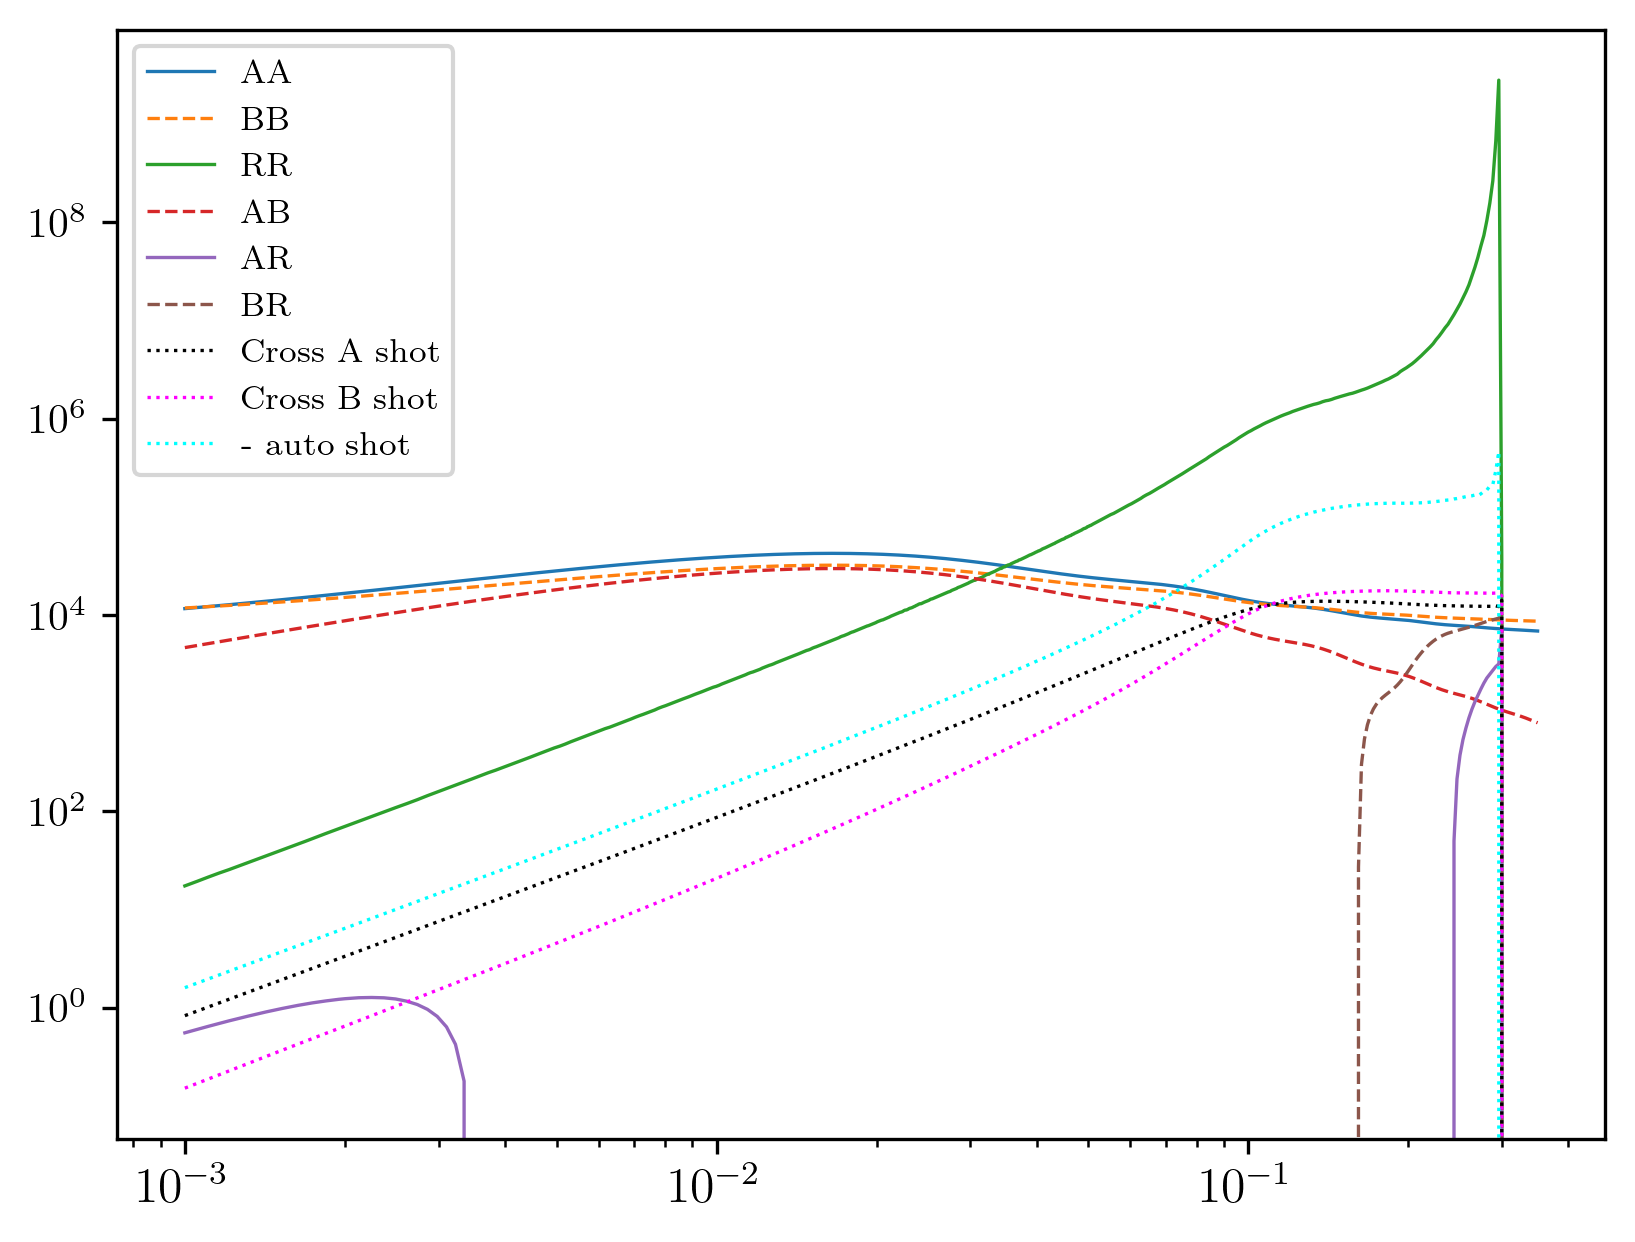

In [9]:
labels = ["AA", "BB", "RR", "AB", "AR", "BR"]
for i, qty in enumerate([CAA, CBB, CRR, CAB, CAR, CBR]):
    plt.loglog(Ks, qty(v_fiducial), label = labels[i], ls = "--" if "B" in labels[i] else "-")
    
plt.plot(Ks, QR.get_get_bispectrum_mixed()(key), color = "black", ls = ":", label = "Cross A shot")
plt.plot(Ks, QR.get_get_bispectrum_mixed_withB()(key), color = "magenta", ls = ":", label = "Cross B shot")
plt.plot(Ks, -(QR.get_get_trispectrum()(key)), color = "cyan", ls = ":", label = "- auto shot")

plt.legend()

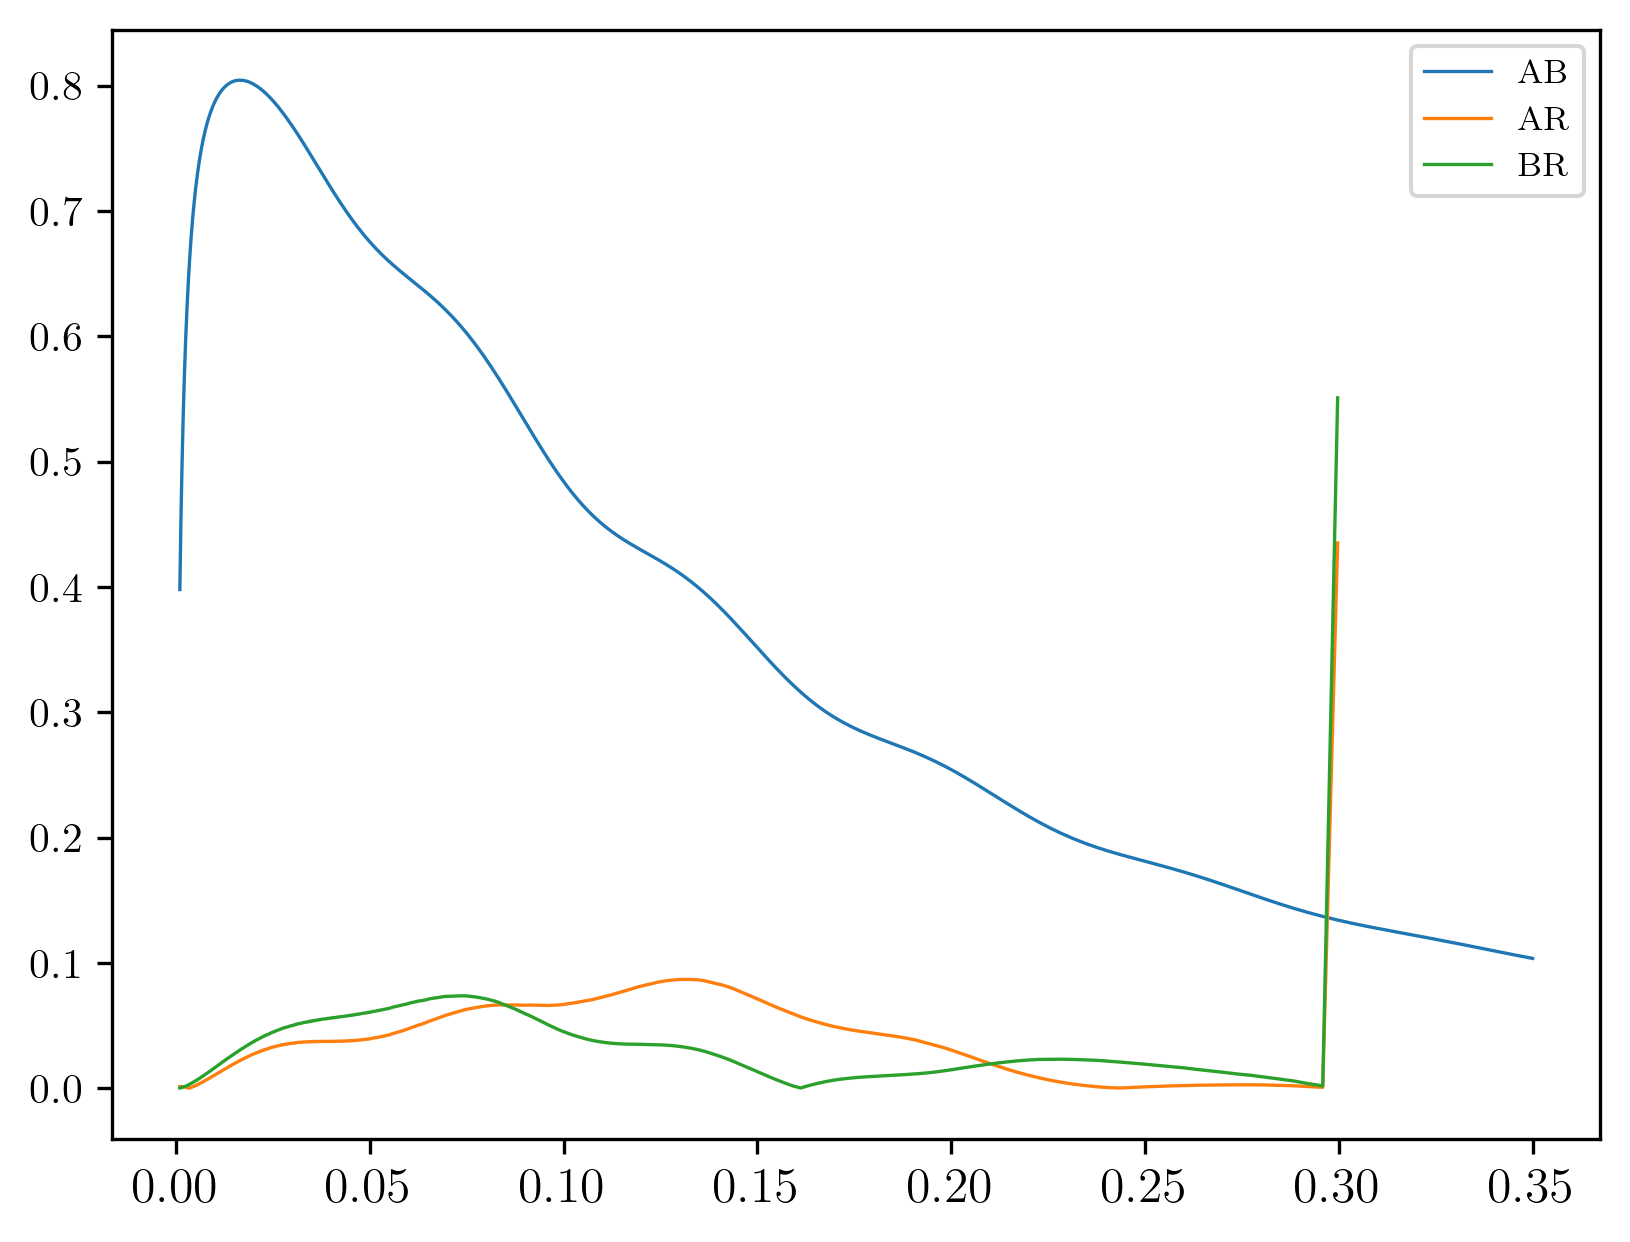

In [10]:
#cross-correlation coefficients
def rho(a, b, c):
    return jnp.sqrt(c(v_fiducial)**2/(a(v_fiducial)*b(v_fiducial)))

#[CAA, CBB, CRR, CAB, CAR, CBR]

plt.plot(Ks, rho(CAA, CBB, CAB), label = "AB")
plt.plot(Ks, rho(CAA, CRR, CAR), label = "AR")
plt.plot(Ks, rho(CBB, CRR, CBR), label = "BR")
plt.legend()

In [11]:
configs = {}
configs["base"] = '../../configs/abacus/config_desi_example_forecast_base.yaml'
configs["high_kmax"] = '../../configs/abacus/config_desi_example_forecast_high_kmax.yaml'
configs["high_n"] = '../../configs/abacus/config_desi_example_forecast_high_n.yaml'
configs["high_n_high_kmax"] = '../../configs/abacus/config_desi_example_forecast_high_n_high_kmax.yaml'


F_out = {}
Ks_out = {}
for c, v in configs.items():
    X_ = fore.Forecaster(v)
    Fisher_results = X_.get_all_fisher(v_fiducial, X_.Ks, key, key_alt = "g", relative_path = "../.")
    F_out[c] = Fisher_results
    Ks_out[c] = X_.Ks


F_out_realistic = {}
for c, v in configs.items():
    X_ = fore.Forecaster(v)
    Fisher_results = X_.get_all_fisher(v_fiducial_realistic, X_.Ks, key, key_alt = "g", relative_path = "../.")
    F_out_realistic[c] = Fisher_results

/tmp/ipykernel_17497/2841374364.py:13: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 1)


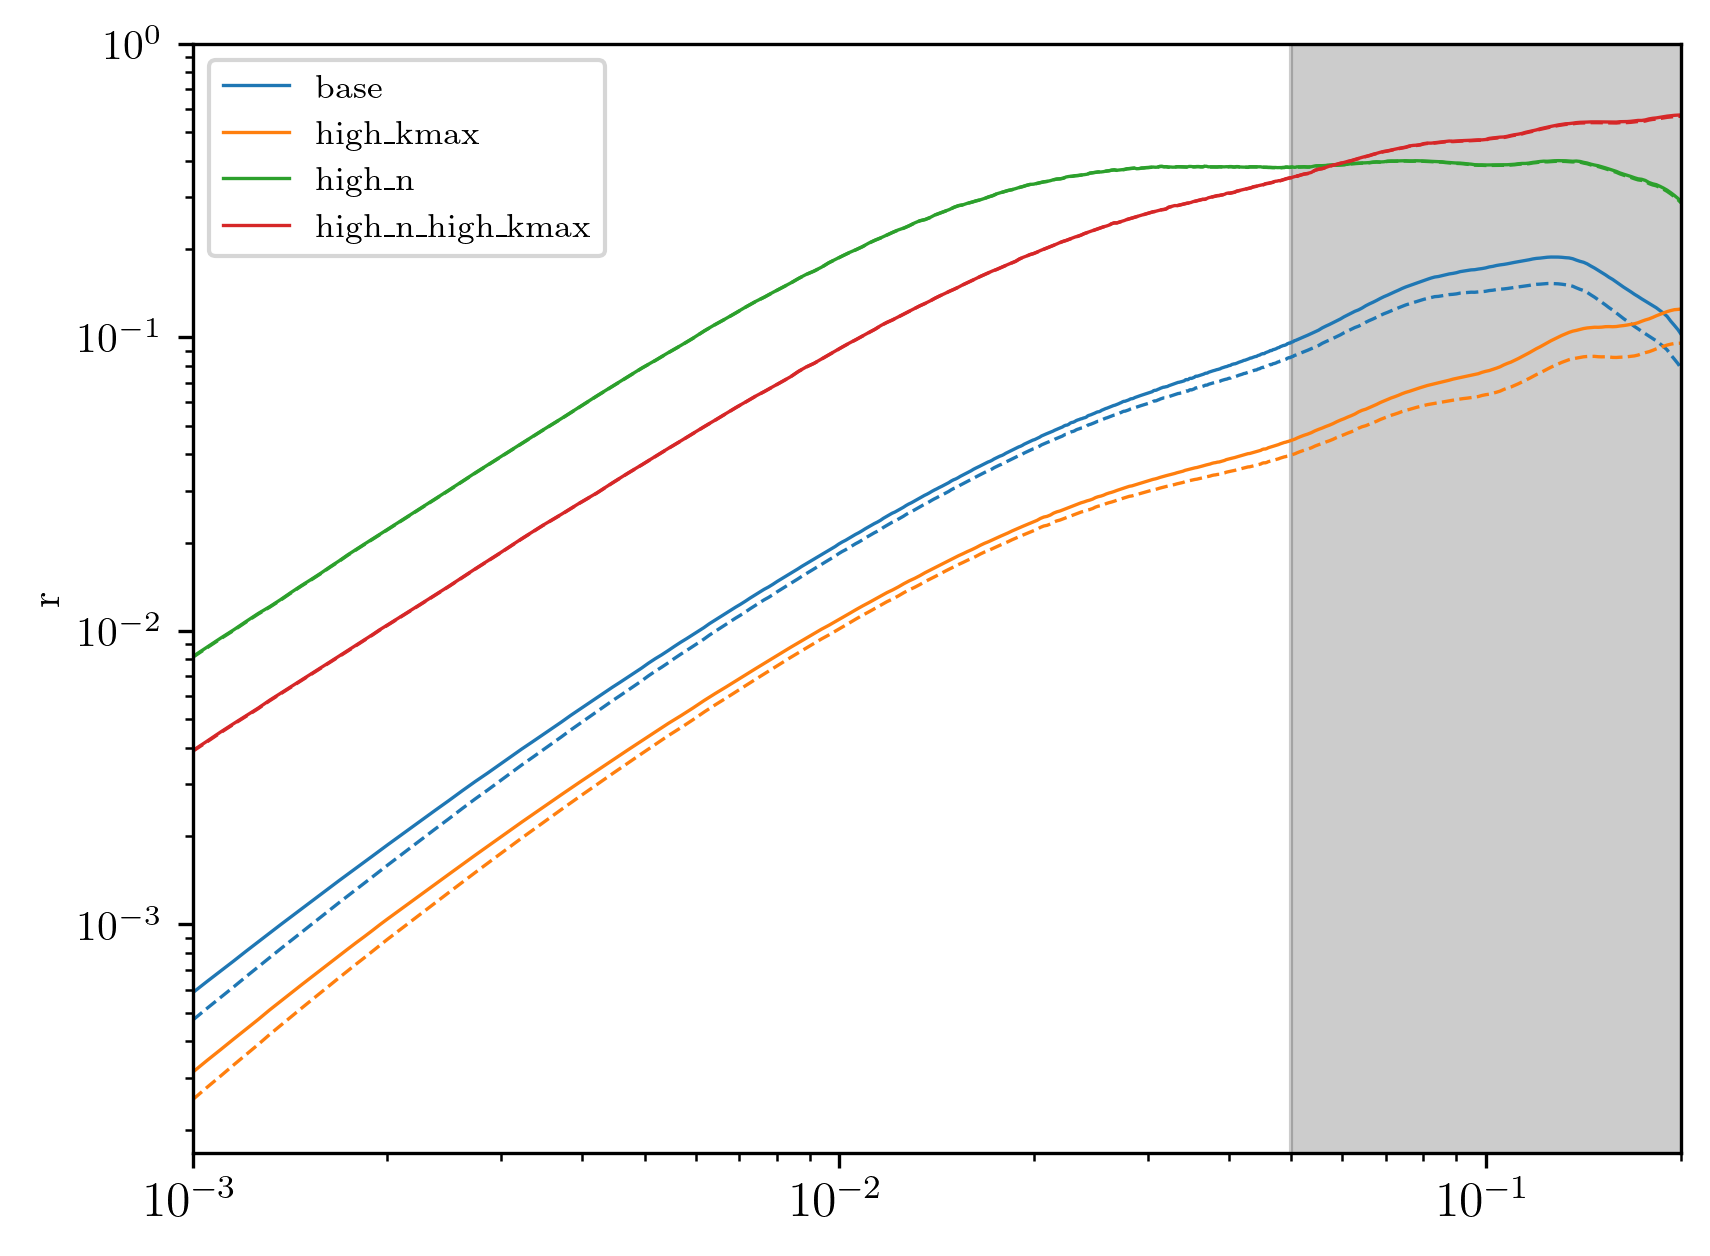

In [12]:
for c, v in configs.items():
    with open(v, 'r') as f:
        conf_temp = yaml.safe_load(f)
    QR_temp = qres.QEResults(conf_temp, relative_path="../.")
    X_temp = fore.Forecaster(v, bispectrum_factor = 0., trispectrum_factor = 0.)
    CAA, CBB, CRR, CAB, CAR, CBR = X_temp.get_functions(QR_temp, "n", key2 = None)
    #y = QR_temp.get_get_variance()("n")
    y = rho(CAA, CRR, CAR)
    p = plt.loglog(X_temp.Ks, y, label = c)
    y = rho(CBB, CRR, CBR)
    plt.loglog(X_temp.Ks, y, color = p[0].get_color(), ls = "--")
plt.fill_betweenx([0., 1.], 0.05, 0.3, color = "black", alpha = 0.2)
plt.ylim(0, 1)
plt.xlim(1e-3, 2e-1)
plt.ylabel("r")
plt.legend()

In [13]:
"""
for c, v in configs.items():
    with open(v, 'r') as f:
        conf_temp = yaml.safe_load(f)
    QR_temp = qres.QEResults(conf_temp, relative_path="../.")
    X_temp = fore.Forecaster(v, bispectrum_factor = 0., trispectrum_factor = 0.)
    CAA, CBB, CRR, CAB, CAR, CBR = X_temp.get_functions(QR_temp, "n", key2 = None)
    #y = QR_temp.get_get_variance()("n")
    y = -CAR(v_fiducial)/X_temp.PL_calculated
    p = plt.loglog(X_temp.Ks, y, label = c)
    y = -CBR(v_fiducial)/X_temp.PL_calculated
    plt.loglog(X_temp.Ks, y, color = p[0].get_color(), ls = "--")
plt.fill_betweenx([0., 1.], 0.05, 0.3, color = "black", alpha = 0.2)
#plt.ylim(0, 1)
plt.xlim(1e-3, 2e-1)
plt.ylabel("r")
plt.legend()
"""

'\nfor c, v in configs.items():\n    with open(v, \'r\') as f:\n        conf_temp = yaml.safe_load(f)\n    QR_temp = qres.QEResults(conf_temp, relative_path="../.")\n    X_temp = fore.Forecaster(v, bispectrum_factor = 0., trispectrum_factor = 0.)\n    CAA, CBB, CRR, CAB, CAR, CBR = X_temp.get_functions(QR_temp, "n", key2 = None)\n    #y = QR_temp.get_get_variance()("n")\n    y = -CAR(v_fiducial)/X_temp.PL_calculated\n    p = plt.loglog(X_temp.Ks, y, label = c)\n    y = -CBR(v_fiducial)/X_temp.PL_calculated\n    plt.loglog(X_temp.Ks, y, color = p[0].get_color(), ls = "--")\nplt.fill_betweenx([0., 1.], 0.05, 0.3, color = "black", alpha = 0.2)\n#plt.ylim(0, 1)\nplt.xlim(1e-3, 2e-1)\nplt.ylabel("r")\nplt.legend()\n'

In [14]:
labels = {}
labels["F_AA_cross_base"] = "Cross AA Base"
labels["F_cross_base"] = "Cross Base"
labels["F_joint_base"] = "Joint Base"
labels["F_cross"] = "Cross"
labels["F_cross_full"] = "Cross Full"
labels["F_joint"] = "Joint"
labels["F_joint_full"] = "Joint Full"
labels["F_joint_full_trace"] = "Joint Full Trace"
labels["F_joint_full_trace_growth_only"] = "Joint Full Trace Growth Only"
labels["F_growth_joint_tr"] = "Joint+Growth Full Trace"
labels["F_joint_full_trace_A_only"] = "Joint A"
labels["F_cross_with_growth"] = "Cross Growth"
labels["F_joint_with_growth"] = "Joint with Growth"


linestyles = {}

def plotf(Ks, F, label, ls = "-", marg = False, index = 0, color = None):
    exponent = -0.5 if not marg else 0.5
    return plt.loglog(Ks, F[:, index, index]**exponent, label = label, ls = ls, color = color)

def getls(k):
    ls = "-" if "cross" in k else "--"
    ls = ls if "full" not in k else ":"
    return ls

"""
#alt way to get fisher tracer with sympy
F_cov = fisher.FisherCov()
Cfunc = fore.get_cov_with_AB(*ps_joint_full)
F_cov_out = F_cov(Cfunc, v_fiducial, Ks)
"""

'\n#alt way to get fisher tracer with sympy\nF_cov = fisher.FisherCov()\nCfunc = fore.get_cov_with_AB(*ps_joint_full)\nF_cov_out = F_cov(Cfunc, v_fiducial, Ks)\n'

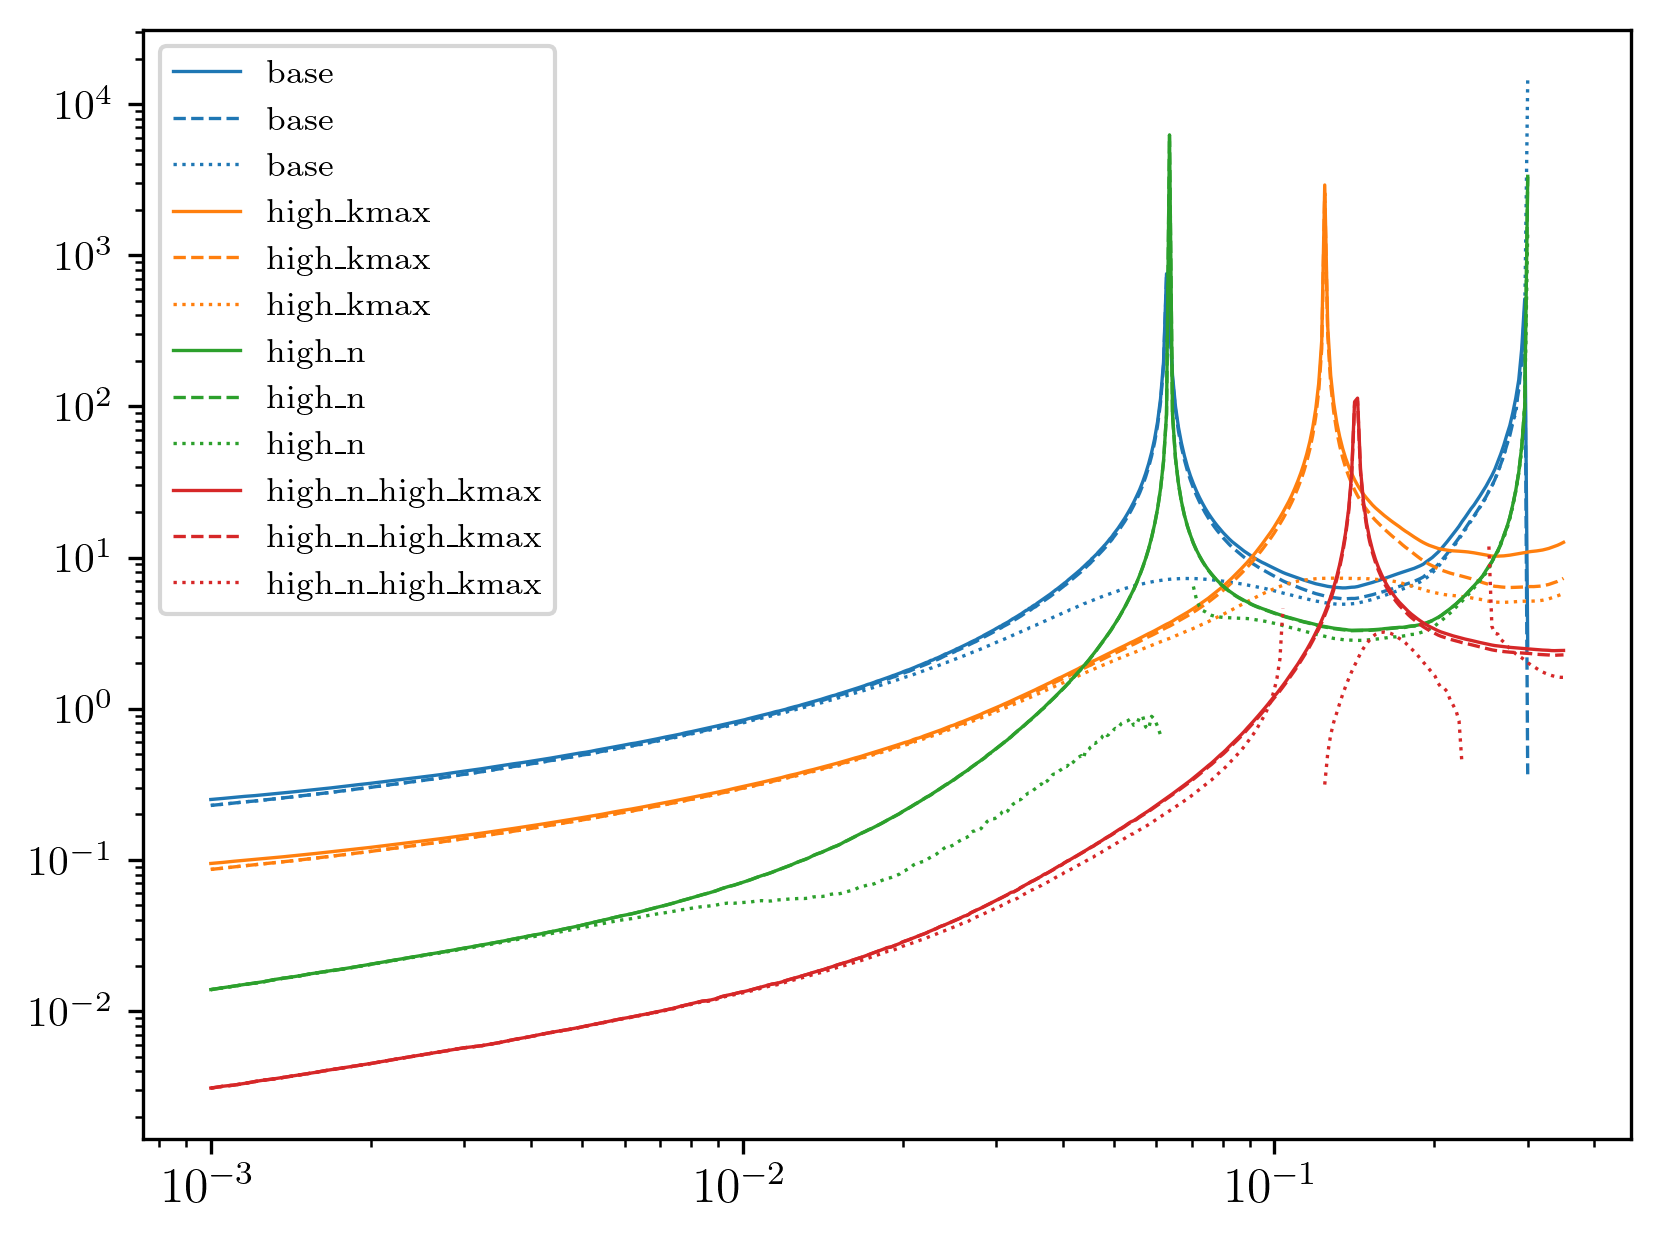

In [15]:
for c, F in F_out.items():
    k = "F_AA_cross_base"
    p = plotf(Ks_out[c], F[k], label = c, ls = getls(k))

    k = "F_joint_base"
    plotf(Ks_out[c], F[k], label = c, ls = getls(k), color = p[0].get_color())

    k = "F_joint_with_growth"
    plotf(Ks_out[c], F[k], label = c, ls = ":", color = p[0].get_color())

    #k = "F_growth_joint_tr"
    #plotf(F[k], label = c, ls = getls(k), color = p[0].get_color())

#plotf(Fisher_results[k], label = "", ls = "--", color = "black")

#plotf(F_out["high_n_high_kmax"]["F_joint_full_trace"], label = "", ls = "-", color = "red")
#plotf(Fisher_results["F_joint_full_trace"], label = "", ls = "-", color = "black")
#plotf(Fisher_results["F_cross"], label = "", ls = ":", color = "cyan")

"""
plt.plot(Ks, analytical**-0.5)
plotf(Y.Ks, Fisher_results["F_joint_full_trace_A_only"], label = "", ls = ":", color = "red")
"""
#plt.plot(Ks, analytical_cross_rr**-0.5, color = "black")

plt.legend()

## Theory expressions

In [16]:
v = configs["high_n_high_kmax"]

with open(v, 'r') as f:
    config = yaml.safe_load(f)
QR_ = qres.QEResults(config, relative_path="../.")

fac = 1e-5
Y = fore.Forecaster(v, shot_noise_A = fac, shot_noise_B = fac, variance_factor = fac, bispectrum_factor = fac, trispectrum_factor = fac)
Fisher_results = Y.get_all_fisher(v_fiducial, Y.Ks, key, key_alt = "g", relative_path = "../.")

keys = ["g", "s", "t", "ga", "sa", "ta"]
bias_per_mode = lambda v: fore.get_tot_bias(v, QR_.get_get_norm()(key),  qres.get_normalization_array(key, keys, Y.Ks, QR_.get_out_normalization_AB()))
b_epsilon = jax.jacfwd(bias_per_mode)(v_fiducial)[:, 0]
bias_per_mode = bias_per_mode(v_fiducial)

#Y = fore.Forecaster(configuration)
CAA, CBB, CRR, CAB, CAR, CBR = Y.get_functions(QR_, "n", key2 = None)
r2 = rho(CAA, CRR, CAR)**2

analytical = (b_epsilon/bias_per_mode)**2*(2-r2)/(1-r2)
analytical_cross = 0.5*(b_epsilon/bias_per_mode)**2

analytical_cross_aa = 0.5*(b_epsilon/b1A)**2*(1+r2)/(1-r2)

analytical_cross_rr = (b_epsilon/bias_per_mode)**2*(2-r2)/(1-r2)



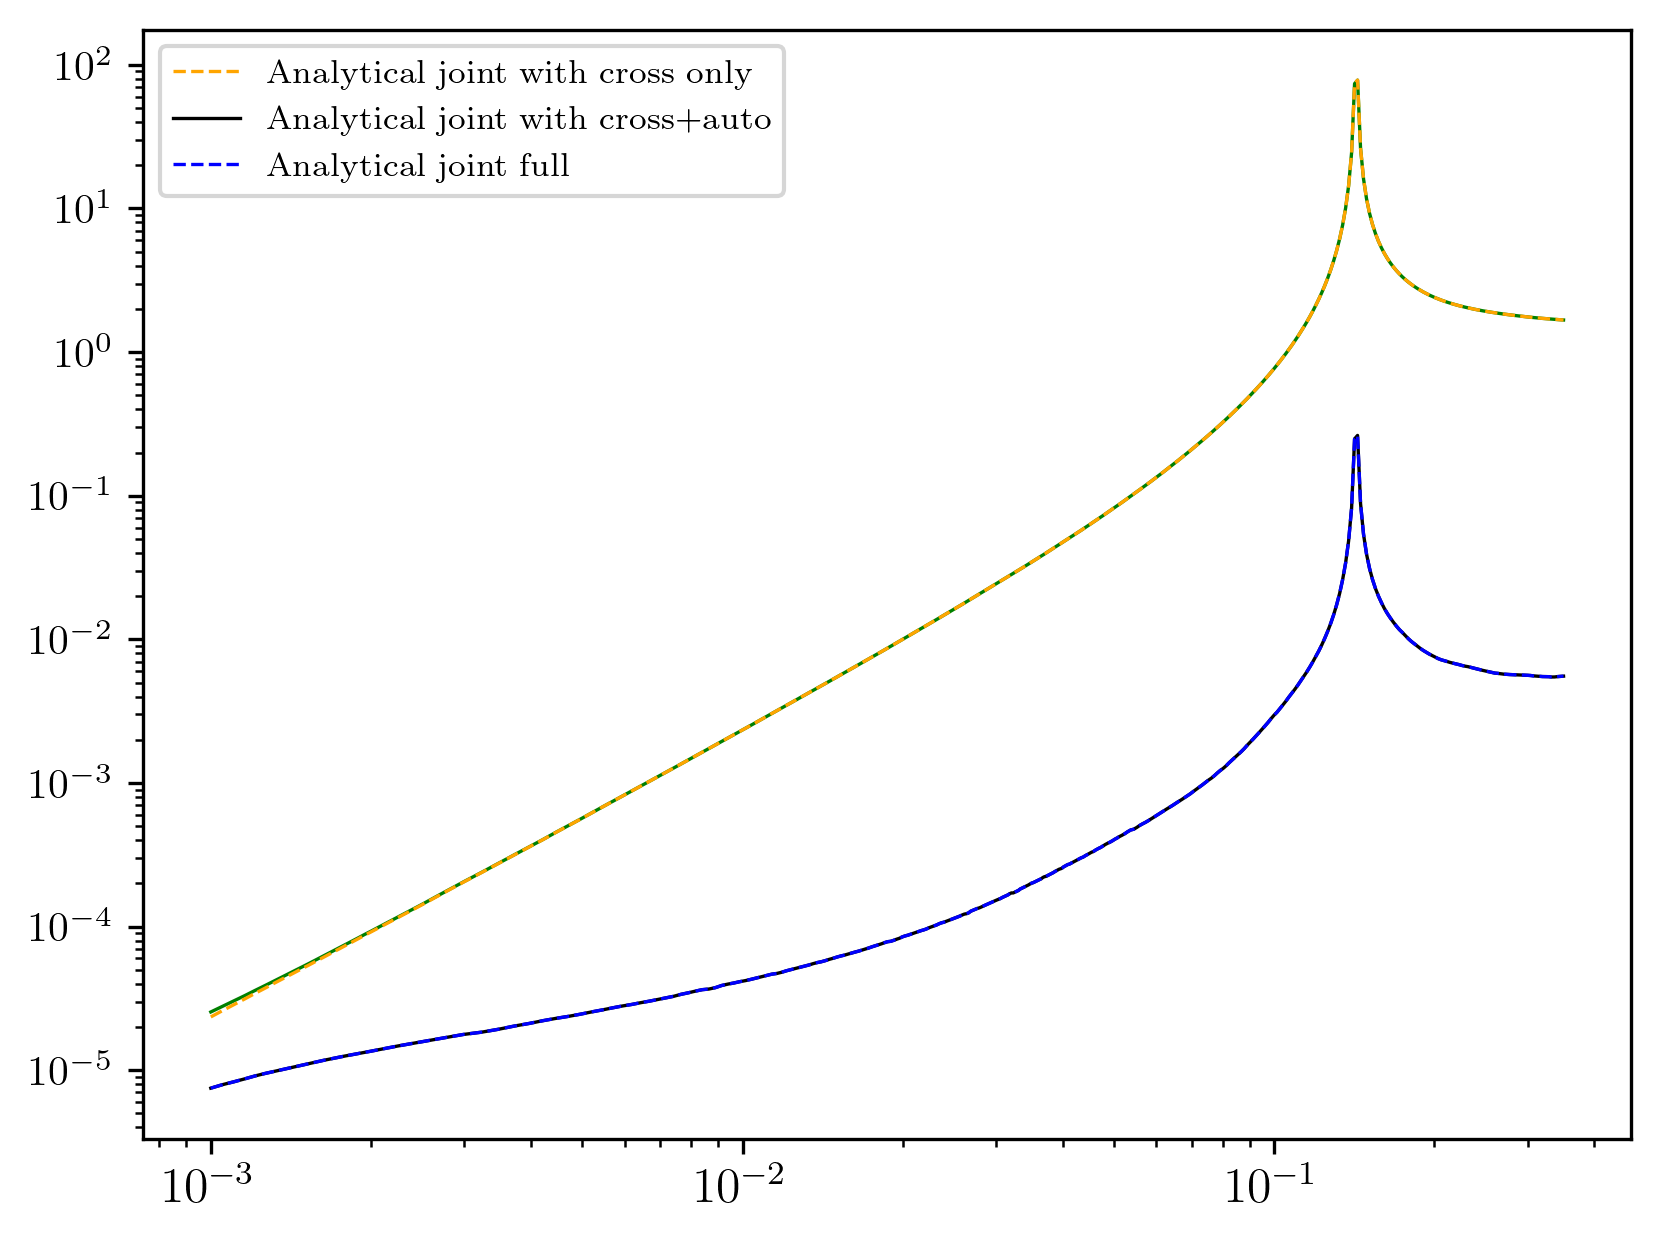

In [17]:
plotf(Y.Ks, Fisher_results["F_AA_cross_base"], label = "", ls = "-", color = "green")
#plotf(Y.Ks, Fisher_results["F_joint"], label = "", ls = "--", color = "red")

plt.plot(Y.Ks, analytical_cross**-0.5, color = "orange", ls = "--", label = "Analytical joint with cross only")

#plt.plot(Y.Ks, analytical_cross_aa**-0.5, color = "purple", label = "Analytical joint with cross+auto galaxy")

plt.loglog(Y.Ks, analytical_cross_rr**-0.5, color = "black", ls = "-", label = "Analytical joint with cross+auto")
plt.loglog(Y.Ks, analytical**-0.5, color = "blue", ls = "--", label = "Analytical joint full")

plt.legend()
#plt.plot(Y.Ks, F_out_symbol[0]**-0.5, ls = "--")

# Switching on and off the epsilon term

We are going to use the whole set of observables

In [18]:
Fisher_results.keys()

dict_keys(['F_AA_cross_base', 'F_cross_base', 'F_joint_base', 'F_cross', 'F_cross_full', 'F_joint', 'F_joint_full', 'F_joint_full_trace', 'F_joint_full_trace_A_only', 'F_joint_full_trace_growth_only', 'F_growth_joint_tr', 'F_joint_full_trace_growth_only_A_only', 'F_joint_with_growth', 'F_cross_with_growth', 'F_cross_base_growth', 'F_joint_base_growth', 'F_AA_cross_base_growth', 'F_RR_cross_base_growth'])

<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_17497/1028403474.py:7: SyntaxWarning: invalid escape sequence '\e'
  labels = ["$\epsilon$", "$b_{1A}$", "$b_{1B}$", "$b_{2A}$", "$b_{2B}$"]


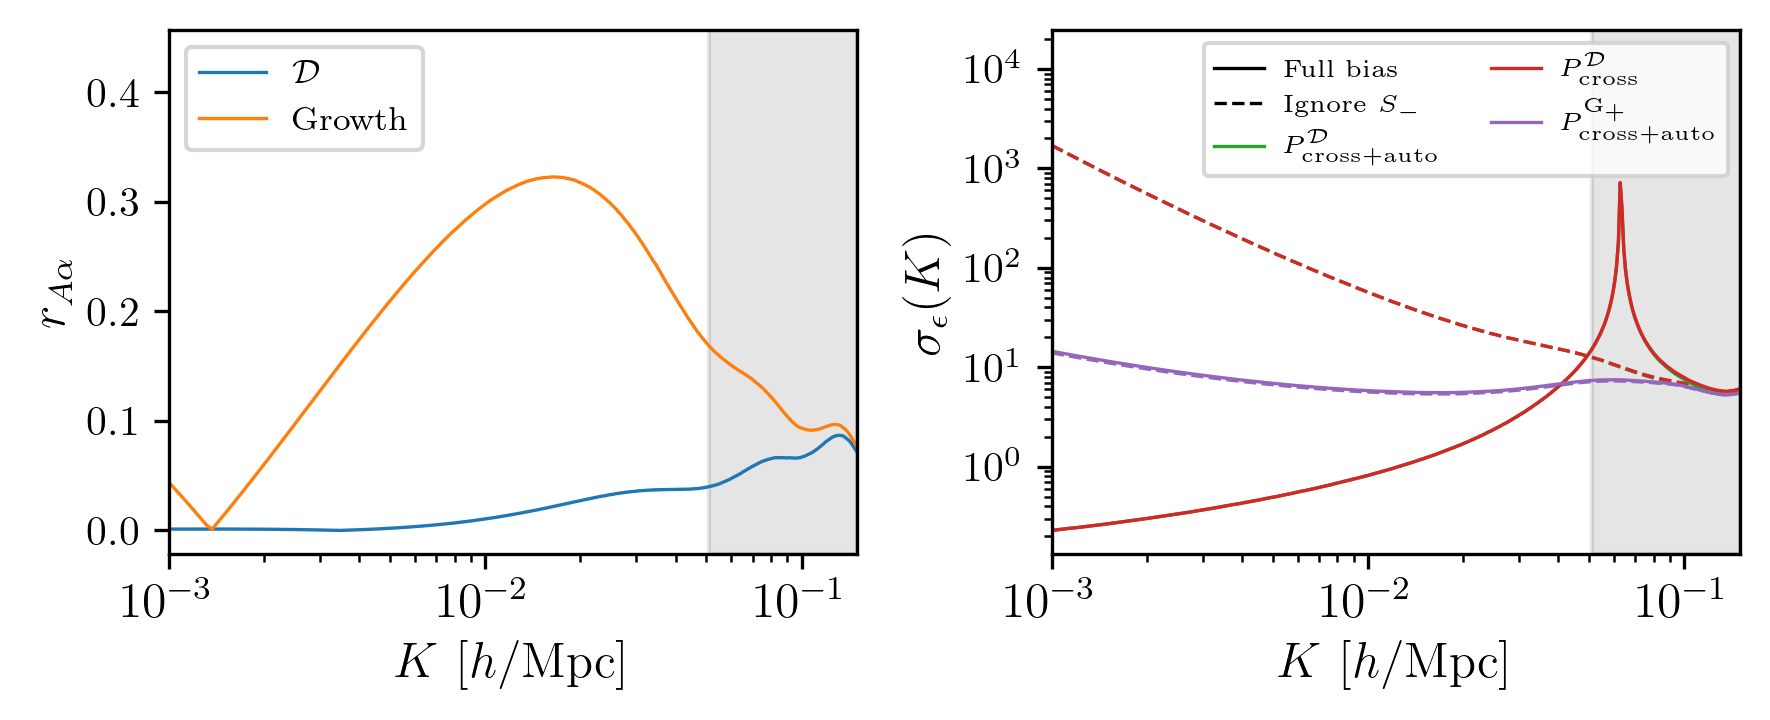

In [19]:
from matplotlib.lines import Line2D


indices = [0]#, 1, 2]
fig, axs = plt.subplots(1, 2, figsize=(6, 2.5), dpi=plot.DPI, facecolor='white')
#axs = [axs]
labels = ["$\epsilon$", "$b_{1A}$", "$b_{1B}$", "$b_{2A}$", "$b_{2B}$"]

#fig.suptitle("Per mode error bars: including (dashed) or not (solid) asymm shift bias", fontsize = 4)

F_out_fish = {}

v_fiducial  = jnp.array([0, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])

key = "n"
key2 = None

asymm_shift = 1
Y = fore.Forecaster(configuration, asymm_shift = asymm_shift)

CAA_for_cov, CBB_for_cov, CRR_for_cov, CAB_for_cov, CAR_for_cov, CBR_for_cov = Y.get_functions(QR, key, key2 = key2)
_, covariance_func_fixed_cross = fore.get_Ofuncs_AB_cross(CAA_for_cov, CBB_for_cov, CRR_for_cov, CAB_for_cov, CAR_for_cov, CBR_for_cov)
_, covariance_func_fixed_joint = fore.get_Ofuncs_AB_joint(CAA_for_cov, CBB_for_cov, CRR_for_cov, CAB_for_cov, CAR_for_cov, CBR_for_cov)

def rho(a, b, c):
    return jnp.sqrt(c(v_fiducial)**2/(a(v_fiducial)*b(v_fiducial)))
    
r2_shift = CAR_for_cov(v_fiducial)**2/CRR_for_cov(v_fiducial)/CAA_for_cov(v_fiducial)

CAA_for_cov, CBB_for_cov, CRR_for_cov, CAB_for_cov, CAR_for_cov, CBR_for_cov = Y.get_functions(QR, "g", key2 = key2)
_, covariance_func_fixed_joint_growth = fore.get_Ofuncs_AB_joint(CAA_for_cov, CBB_for_cov, CRR_for_cov, CAB_for_cov, CAR_for_cov, CBR_for_cov)

r2_growth = CAR_for_cov(v_fiducial)**2/CRR_for_cov(v_fiducial)/CAA_for_cov(v_fiducial)

axs[0].plot(Ks, jnp.sqrt(r2_shift), label = r"$\mathcal{D}$")
axs[0].plot(Ks, jnp.sqrt(r2_growth), label = r"Growth")
axs[0].set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=12)
axs[0].set_ylabel(r'$r_{A\alpha}$', fontsize=12)
axs[0].legend()
axs[0].set_xscale("log")
axs[0].axvspan(QR.kmin, QR.kmax, alpha=0.1, color = 'black')
axs[0].set_xlim(1e-3, 1.5e-1)

for index_case, asymm_shift in enumerate([0, 1]):

    Y = fore.Forecaster(configuration, asymm_shift = asymm_shift)
    Fisher_results = Y.get_all_fisher(v_fiducial, Y.Ks, key, key_alt = "g", relative_path = "../.")
    F_cross = Fisher_results["F_cross_base"]
    F_joint = Fisher_results["F_joint_base"]
    F_joint_g = Fisher_results["F_joint_base_growth"]
    
    for i, index in enumerate(indices):
        ax = axs[i+1]
        #ax.set_title(labels[i])
        fac = Ks**2
        fac = 1
        ax.loglog(Ks, (fac*F_joint[:, index, index])**-0.5, label = "Joint" if index_case == 1 else None, color = plot.COLORBLIND_PALETTE_2[2], ls = "--" if index_case == 0 else "-")
        ax.loglog(Ks, (fac*F_cross[:, index, index])**-0.5, color = plot.COLORBLIND_PALETTE_2[3], label = "Cross-only" if index_case == 1 else None, ls = "--" if index_case == 0 else "-")

        ax.loglog(Ks, (fac*F_joint_g[:, index, index])**-0.5, label = "Joint Growth Only" if index_case == 1 else None, color = plot.COLORBLIND_PALETTE_2[4], ls = "--" if index_case == 0 else "-")

        ax.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=12)
        ax.set_ylabel(r'$\sigma_\epsilon(K)$', fontsize=12)
        ax.set_xlim(1e-3, 1.5e-1)
        #ax.set_ylim(1e-6)

ax.axvspan(QR.kmin, QR.kmax, alpha=0.1, color = 'black')

legend_elements = [
                    Line2D([0], [0], color = 'black', ls = "-", label='Full bias'),
                    Line2D([0], [0], color = 'black', ls = "--", label='Ignore $S_{-}$'),
                    Line2D([0], [0], color = plot.COLORBLIND_PALETTE_2[2], label=r'$P^{\mathcal{D}}_{\mathrm{cross+auto}}$'),
                    Line2D([0], [0], color = plot.COLORBLIND_PALETTE_2[3], label=r'$P_{\mathrm{cross}}^{\mathcal{D}}$'),
                    Line2D([0], [0], color = plot.COLORBLIND_PALETTE_2[4], label=r'$P^{\mathrm{G}_+}_{\mathrm{cross+auto}}$')
                   ]

ax.legend(handles=legend_elements, loc='best', ncol = 2, fontsize = 6)
fig.tight_layout()
fig.savefig(f"figures/fisher_per_mode_ignore_shift.pdf", dpi = 300, bbox_inches='tight')

In [20]:
def interpolate_matrix_reshape(F_joint_AB, Ks, KK):
    """
    More efficient version using reshape
    """
    M, N1, N2 = F_joint_AB.shape
    K = len(KK)
    
    # Reshape to (M, N1*N2) for batch interpolation
    F_reshaped = F_joint_AB.reshape(M, -1)
    
    # Interpolate each column (each (i,j) pair)
    def interp_column(col):
        return jnp.interp(KK, Ks, col)
    
    F_interp_flat = jax.vmap(interp_column, in_axes=1)(F_reshaped)
    
    # Reshape back to (K, N1, N2)
    F_interp = F_interp_flat.T.reshape(K, N1, N2)
    
    return F_interp

#try to interpolate before integrating
KK = jnp.linspace(Ks.min(), Ks.max(), 2000)

In [21]:
#integrate full matrices now, to check marginalization
Kmax_ = 5e-2
selected = [0, 1, 2, 3, 4, 5, 6]#+[7, 8, 9, 10]
Narr = 50

for i in F_out_fish.keys():
    
    F_cross_AB, F_joint_AB = F_out_fish[i]
    modes, F_ = fisher.get_integrated_fisher(Ks, F_joint_AB[:, selected, :][:, :, selected], Narr = Narr, Kmax = Kmax_)
    F_inv = jnp.linalg.inv(F_)
    plt.loglog(modes, F_inv[:, 0, 0]**0.5, ls = "--" if i == 0 else "-", color = plot.COLORBLIND_PALETTE_2[3])

    modes, F_ = fisher.get_integrated_fisher(KK, interpolate_matrix_reshape(F_joint_AB, Ks, KK)[:, selected, :][:, :, selected], Narr = Narr, Kmax = Kmax_)
    F_inv = jnp.linalg.inv(F_)
    plt.loglog(modes, F_inv[:, 0, 0]**0.5, color = "black")
    
    #modes, F = get_integrated_fisher(Ks, F_cross_AB[:, :1, :1], Narr = 50)
    modes, F = fisher.get_integrated_fisher(Ks, F_joint_AB[:, selected, :][:, :, selected], Narr = Narr, method = 1, Kmax = Kmax_)
    F_inv = jnp.linalg.inv(F)
    plt.loglog(modes, F_inv[:, 0, 0]**0.5, ls = "--" if i == 0 else "-", color = plot.COLORBLIND_PALETTE_2[2])

    modes, F = fisher.get_integrated_fisher(Ks, F_joint_AB[:, selected, :][:, :, selected], Narr = Narr, method = 2, Kmax = Kmax_)
    F_inv = jnp.linalg.inv(F)
    plt.loglog(modes, F_inv[:, 0, 0]**0.5, ls = "--" if i == 0 else "-", color = plot.COLORBLIND_PALETTE_2[4])

    #modes, F = get_integrated_fisher(Ks, F_joint_AB[:, selected, :][:, :, selected], Narr = Narr, method = 3, Kmax = Kmax_)
    #F_inv = jnp.linalg.inv(F)
    #plt.loglog(modes, F_inv[:, 0, 0]**0.5, ls = "--" if i == 0 else "-", color = plot.COLORBLIND_PALETTE_2[5])
    
    #modes, F = get_integrated_fisher(Ks, F_joint_AB, Narr = 50, method = 2, Kmax = Kmax_)
    #F_inv = jnp.linalg.inv(F)
    #plt.loglog(modes, F_inv[:, 0, 0]**0.5, ls = "--" if i == 0 else "-", color = plot.COLORBLIND_PALETTE_2[1])

# Integrated Fisher

In [22]:
def ger_errors(Ks, FisherMatrix, selected, Kmin, Kmax, V, Narr = 50, method = 1):
    modes, F_int = fisher.get_integrated_fisher(Ks, FisherMatrix[:, selected][:, :, selected], Kmin = Kmin, Kmax = Kmax, V = V, Narr = Narr, method = method)
    err_matrix = jnp.array([jnp.diag(F_)**-0.5 for F_ in F_int])
    Cov_int_marg = [jnp.linalg.inv(F_) for F_ in F_int]
    err_marginalized_matrix = jnp.array([jnp.diag(C_)**0.5 for C_ in Cov_int_marg])
    return modes, err_matrix, err_marginalized_matrix, F_int, Cov_int_marg

Ks = X.Ks
Kmax = 5.1e-2
h = 0.67
V = 30  #100*h**3 #in Gpc h^{-3}
V_MPC3 = V*1e9
k_min_analysis = 2*np.pi/V_MPC3**(1/3)
print(k_min_analysis)
print(F_out.keys())

0.002022116238530652
dict_keys(['base', 'high_kmax', 'high_n', 'high_n_high_kmax'])


In [23]:
key_config = 'base'
print(F_out[key_config].keys())

dict_keys(['F_AA_cross_base', 'F_cross_base', 'F_joint_base', 'F_cross', 'F_cross_full', 'F_joint', 'F_joint_full', 'F_joint_full_trace', 'F_joint_full_trace_A_only', 'F_joint_full_trace_growth_only', 'F_growth_joint_tr', 'F_joint_full_trace_growth_only_A_only', 'F_joint_with_growth', 'F_cross_with_growth', 'F_cross_base_growth', 'F_joint_base_growth', 'F_AA_cross_base_growth', 'F_RR_cross_base_growth'])


In [24]:
#key_config = 'base'
#key_forecasts = ["F_cross", "F_joint"]

method = 0

selected = list(range(7))#+[7, 8, 11, 12]
Narr = 150

F_marg = {}
for key_config in F_out.keys():
    F_marg[key_config] = {}
    F_specific = F_out[key_config]
    key_forecasts = F_specific.keys()
    for key_forecast in key_forecasts:
        FF = F_specific[key_forecast]
        modes, err_joint_tr, err_marg_joint_tr, F_int, F_int_marg = ger_errors(Ks_out[key_config], FF, selected, k_min_analysis, Kmax, V, Narr = Narr, method = method)
        F_marg[key_config][key_forecast] = (modes, err_joint_tr, err_marg_joint_tr, F_int, F_int_marg)

In [35]:
F_marg_realistic = {}
for key_config in F_out_realistic.keys():
    F_marg_realistic[key_config] = {}
    F_specific = F_out_realistic[key_config]
    key_forecasts = F_specific.keys()
    for key_forecast in key_forecasts:
        FF = F_specific[key_forecast]
        modes, err_joint_tr, err_marg_joint_tr, F_int, F_int_marg = ger_errors(Ks_out[key_config], FF, selected, k_min_analysis, Kmax, V, Narr = Narr, method = method)
        F_marg_realistic[key_config][key_forecast] = (modes, err_joint_tr, err_marg_joint_tr, F_int, F_int_marg)

In [25]:
configs.keys()

dict_keys(['base', 'high_kmax', 'high_n', 'high_n_high_kmax'])

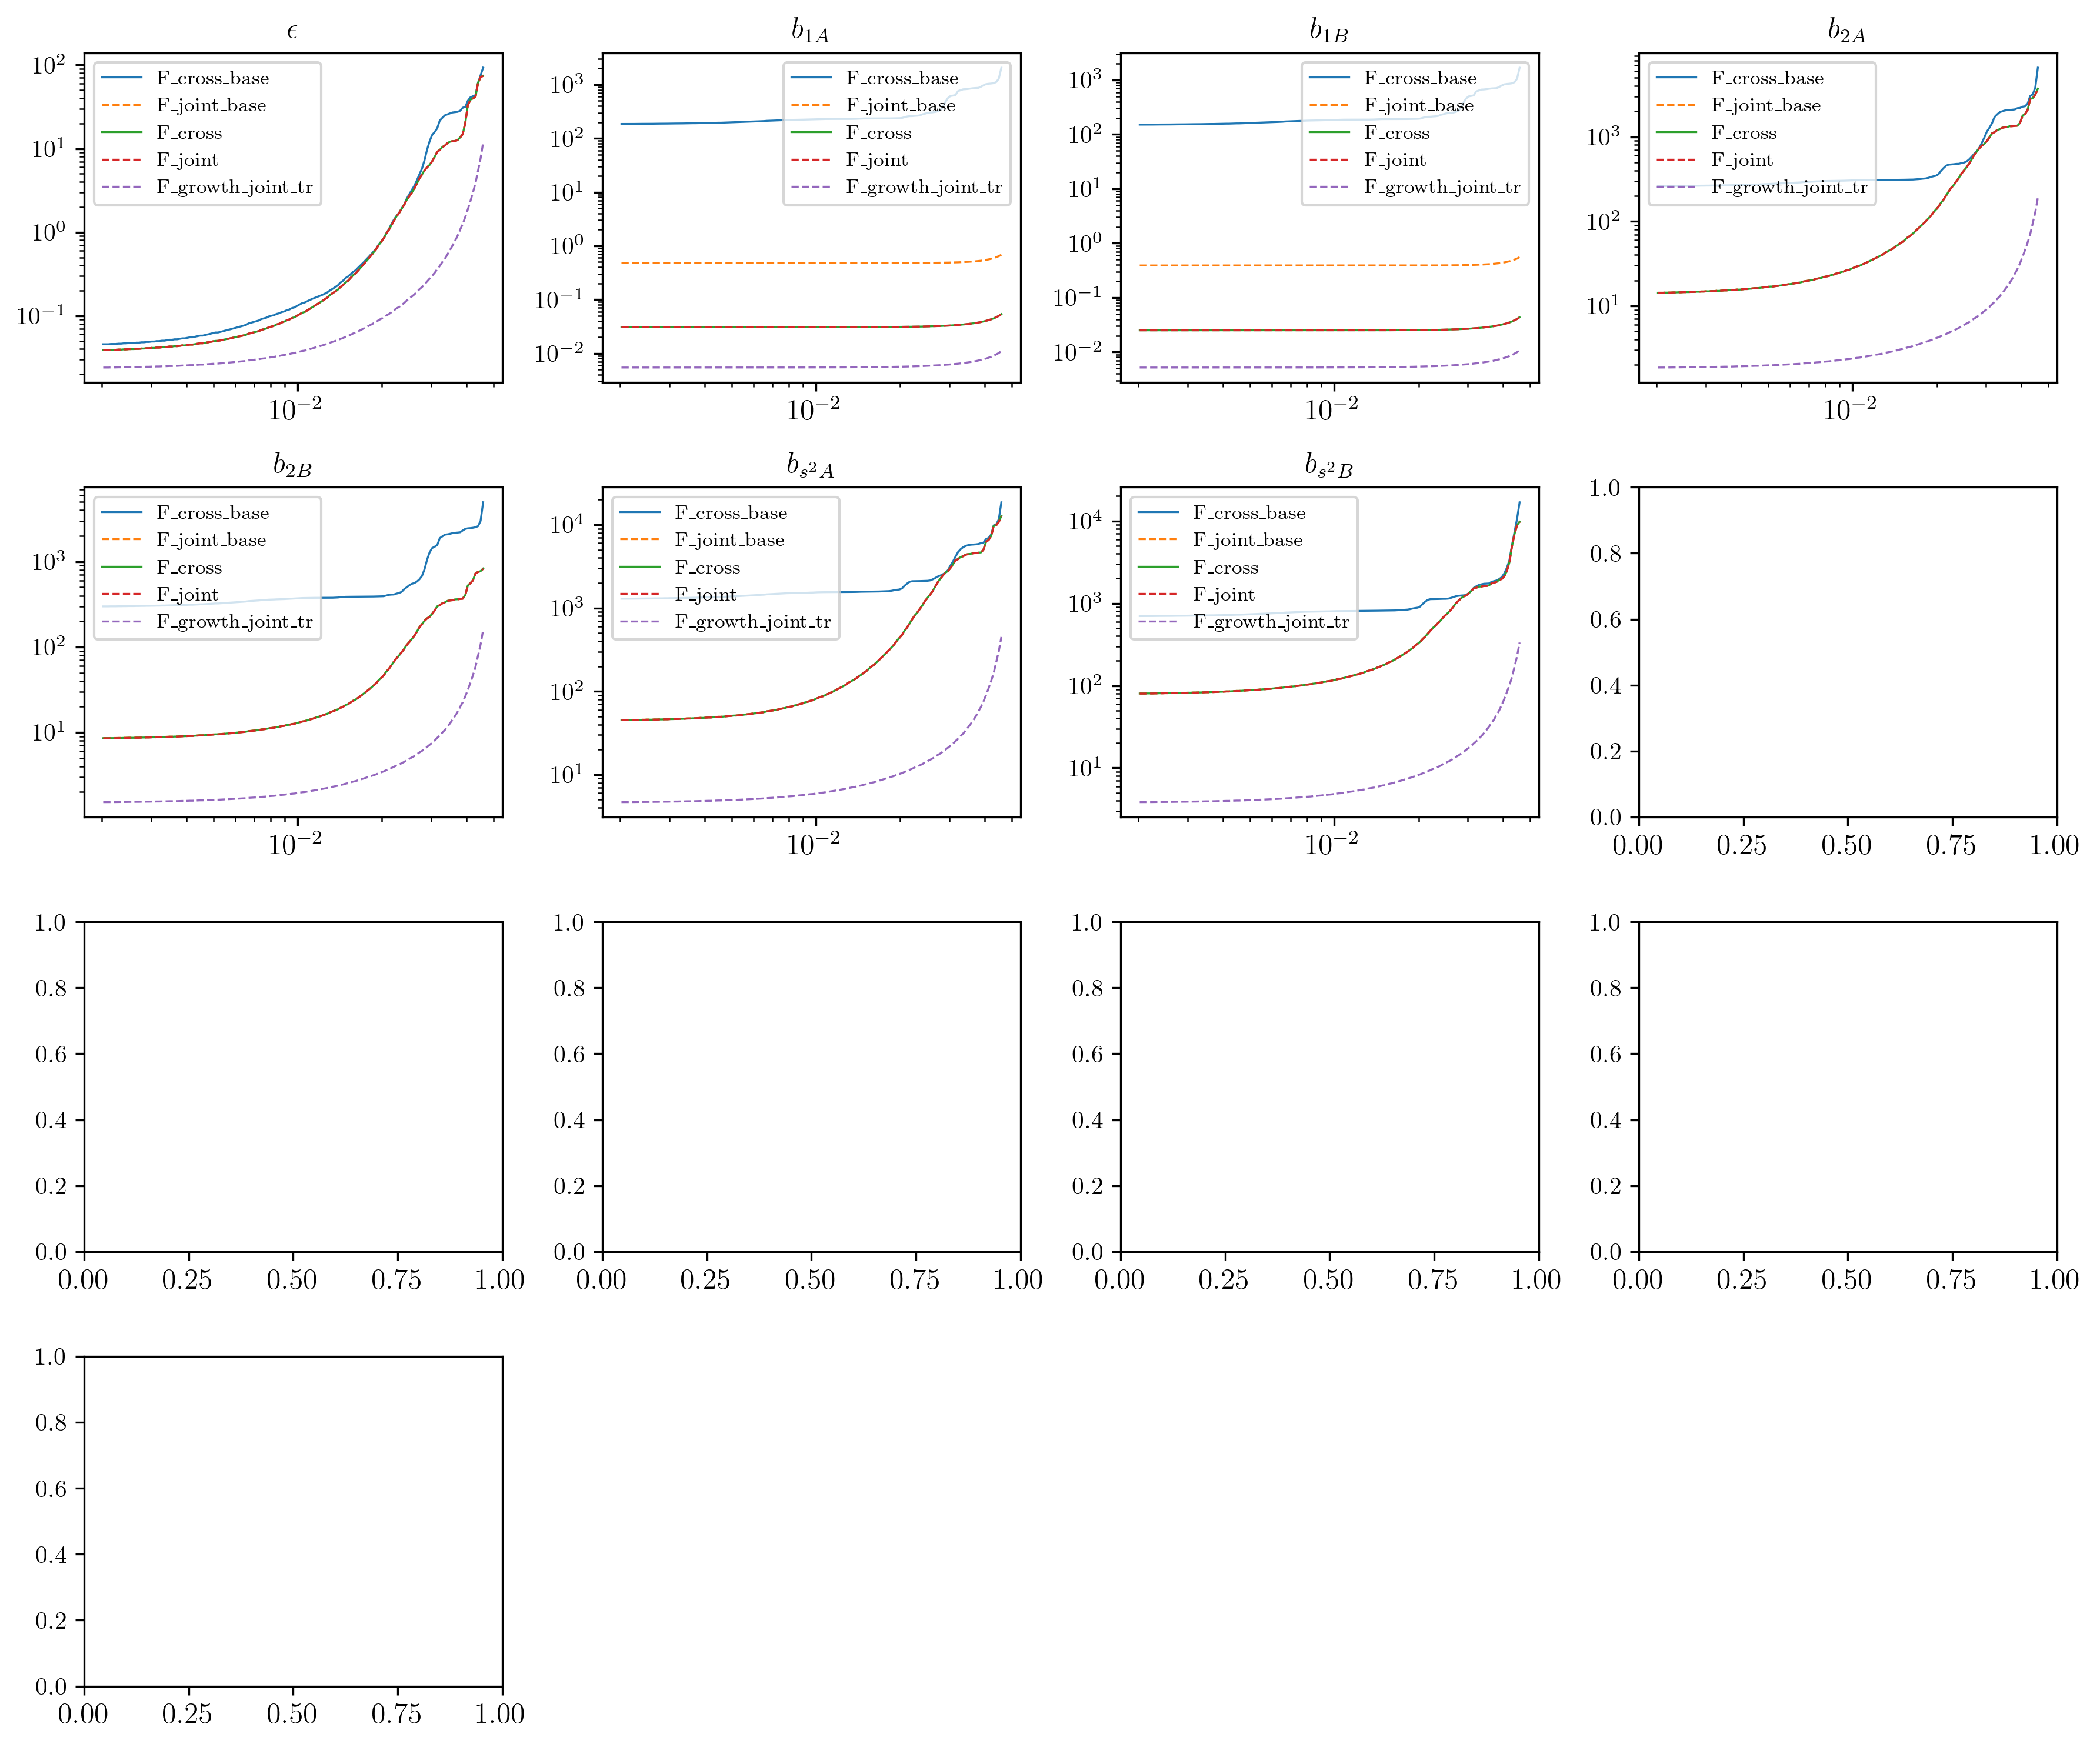

In [26]:
titles = [
    r'$\epsilon$', 
    r'$b_{1A}$', 
    r'$b_{1B}$', 
    r'$b_{2A}$', 
    r'$b_{2B}$', 
    r'$b_{s^2A}$', 
    r'$b_{s^2B}$', 
    r'$b_{\epsilon, GA}$', 
    r'$b_{\epsilon, GB}$', 
    r'$b_{\epsilon, SA}$', 
    r'$b_{\epsilon, SB}$', 
    r'$b_{\epsilon, TA}$', 
    r'$b_{\epsilon, TB}$'
]

key_config = "base"

n, m = 4, 4
fig, axs = plt.subplots(n, m, figsize=(12, 10))

axs_flat = axs.flatten()

for index in range(len(selected)):
    i = index // m  # row index
    j = index % m   # column index
    
    #for key_forecast in key_forecasts:
    for key_forecast in ["F_cross_base", "F_joint_base", "F_cross", "F_joint", "F_growth_joint_tr"]:
        modes, unmarg, marg, _, _ = F_marg[key_config][key_forecast]
        
        axs_flat[index].loglog(modes, marg[:, index], 
                            label=key_forecast, 
                            ls="-" if "cross" in key_forecast else "--")
    
    axs_flat[index].set_title(titles[index])
    axs_flat[index].legend()

for index in range(13, 16):
    axs_flat[index].set_visible(False)

fig.tight_layout()
plt.show()

## Make triangle plots

In [27]:
Npars = 7

In [28]:
key_forecast = "F_cross"
_, _, _, F_unmarg, cov_marg = F_marg[key_config][key_forecast]
unmarg_cov_cross_full = jnp.diag(jnp.diag(F_unmarg[0])**-1.)
cov_cross_full = cov_marg[0]

key_forecast = "F_joint"
_, _, _, F_unmarg, cov_marg = F_marg[key_config][key_forecast]
unmarg_cov_full = jnp.diag(jnp.diag(F_unmarg[0])**-1.)
cov_full = cov_marg[0]

key_forecast = "F_joint_with_growth"
_, _, _, F_unmarg, cov_marg = F_marg[key_config][key_forecast]
unmarg_cov_growth = jnp.diag(jnp.diag(F_unmarg[0])**-1.)
cov_growth = cov_marg[0]

In [29]:
title_triangle = titles[:1]+titles[1:7:2]
v_triangle = jnp.append(v_fiducial[0], v_fiducial[1:7:2])

sel_triangle = [0, 1, 3, 5]
cov_full = cov_full[:, sel_triangle][sel_triangle, :]
cov_cross_full = cov_cross_full[:, sel_triangle][sel_triangle, :]
cov_growth = cov_growth[:, sel_triangle][sel_triangle, :]

sel_triangle = [0, 1]
unmarg_cov_growth = unmarg_cov_growth[:, sel_triangle][sel_triangle, :]
unmarg_cov_full = unmarg_cov_full[:, sel_triangle][sel_triangle, :]
unmarg_cov_cross_full = unmarg_cov_cross_full[:, sel_triangle][sel_triangle, :]

In [30]:
v_triangle[:2].shape, unmarg_cov_growth.shape

((2,), (2, 2))

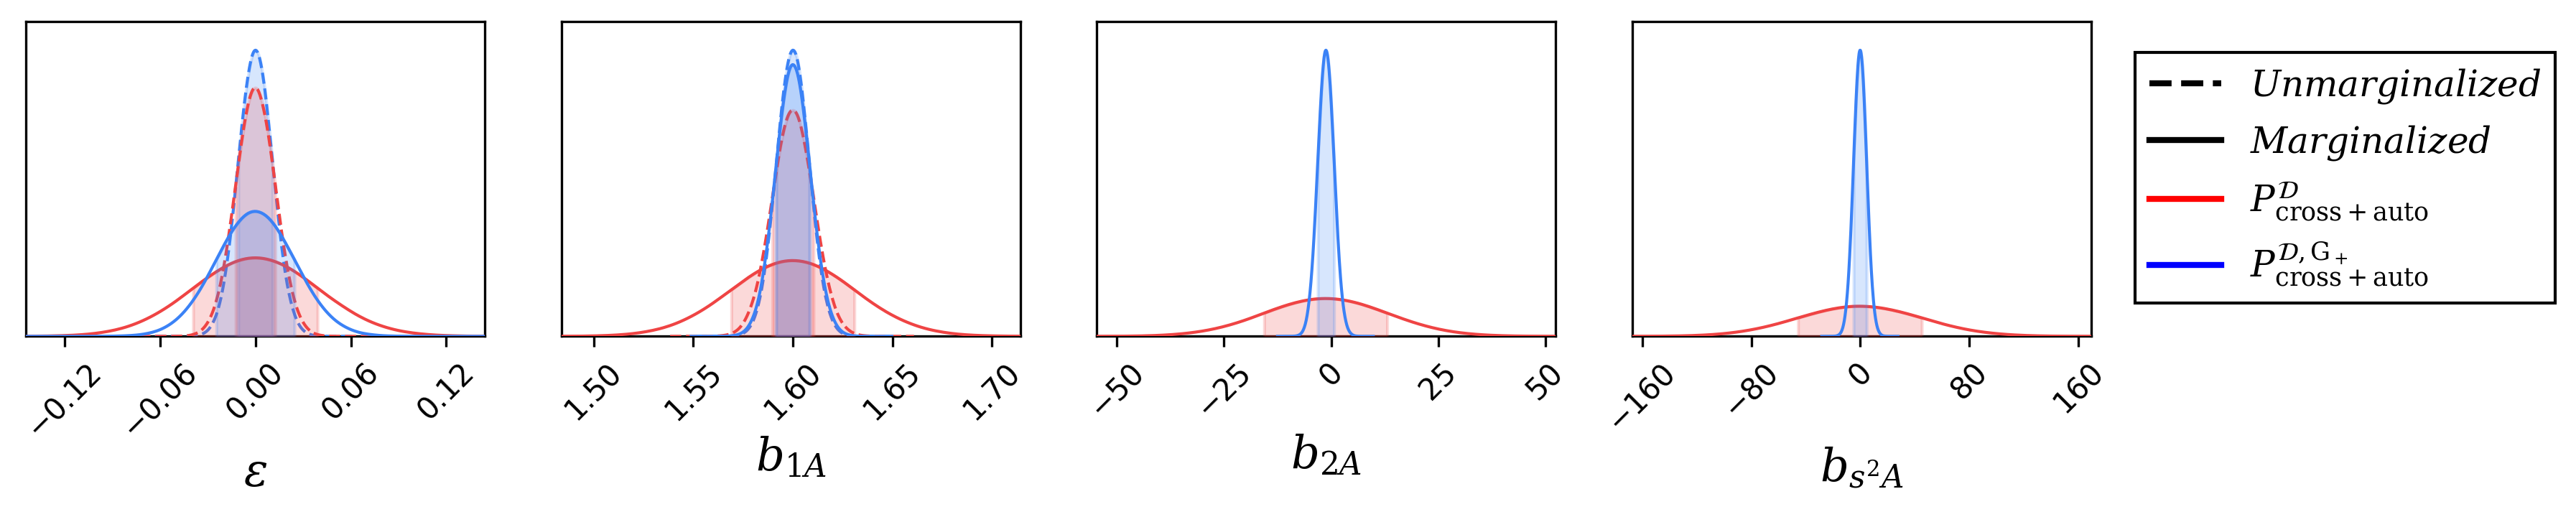

In [31]:
from chainconsumer import Chain, ChainConfig, ChainConsumer, PlotConfig, Truth, make_sample
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Set up the consumer
c = ChainConsumer()

chain3 = Chain.from_covariance(
    v_triangle[:2],
    unmarg_cov_growth,
    columns=title_triangle[:2],
    name=r"$Unmarg Joint+Growth$",
    color="blue",
    linestyle="--",
)
c.add_chain(chain3)

chain4 = Chain.from_covariance(
    v_triangle[:2],
    unmarg_cov_full,
    columns=title_triangle[:2],
    name=r"$Unmarg Joint$",
    color="red",
    linestyle="--",
)
c.add_chain(chain4)

chain1 = Chain.from_covariance(
    v_triangle,
    cov_full,
    columns=title_triangle,
    name=r"$Joint$",
    color="red"
)
c.add_chain(chain1)

chain2 = Chain.from_covariance(
    v_triangle,
    cov_growth,
    columns=title_triangle,
    name=r"$Joint+Growth$",
    color="blue",
)
c.add_chain(chain2)

# Generate the plot
fig = c.plotter.plot_distributions()

# Customize axes
for ax in fig.get_axes():
    ax.tick_params(labelsize=10)
    ax.xaxis.label.set_size(15)
    ax.yaxis.label.set_size(10)

def add_legend_outside_manual(fig):
    """
    Add legend outside the plot area
    """
 
    chain_info = [
        {"name": r"$Unmarginalized$", "color": "black", "linestyle": "--"},
        {"name": r"$Marginalized$", "color": "black", "linestyle": "-"},
        {"name": r"$P^{\mathcal{D}}_{\mathrm{cross+auto}}$", "color": "red", "linestyle": "-"},
        {"name": r"$P^{\mathcal{D},\mathrm{G}_+}_{\mathrm{cross+auto}}$", "color": "blue", "linestyle": "-"}
    ]
    
    handles = []
    labels = []
    
    for chain in chain_info:
        handle = plt.Line2D([0], [0], 
                           color=chain["color"], 
                           linestyle=chain["linestyle"], 
                           linewidth=2)
        handles.append(handle)
        labels.append(chain["name"])
    
    # Add legend to the figure - various position options:
    
    # Option 1: Right side - further outside to avoid overlap
    fig.legend(handles, labels,
              loc='center right',
              bbox_to_anchor=(1.2, 0.65),  # Moved further right
              fontsize=12,
              frameon=True,
              fancybox=False,
              shadow=False,
              framealpha=1.0,
              edgecolor="black",
              facecolor="white")
    
    # Option 2: Top - completely outside all plots (uncomment to use)
    # fig.legend(handles, labels,
    #           loc='upper center',
    #           bbox_to_anchor=(0.5, 1.08),  # Higher up
    #           ncol=4,  # Horizontal layout
    #           fontsize=12,
    #           frameon=True,
    #           fancybox=False,
    #           shadow=False,
    #           framealpha=1.0,
    #           edgecolor="black",
    #           facecolor="white")
    
    # Option 3: Bottom - completely outside all plots (uncomment to use)
    # fig.legend(handles, labels,
    #           loc='lower center',
    #           bbox_to_anchor=(0.5, -0.08),  # Lower down
    #           ncol=4,  # Horizontal layout
    #           fontsize=12,
    #           frameon=True,
    #           fancybox=False,
    #           shadow=False,
    #           framealpha=1.0,
    #           edgecolor="black",
    #           facecolor="white")

# Use legend outside the plot area
add_legend_outside_manual(fig)

# Alternative options (comment out the above and uncomment one of these):
# legend = add_legend_with_consumer_data(fig, c)  # Legend inside first subplot
# legend = add_manual_legend(fig)  # Legend inside first subplot

# Adjust layout
plt.tight_layout()

# Save the figure
fig.savefig(f"figures/distributions.pdf", dpi = 300, bbox_inches='tight')

## Kmin plot

In [37]:
def F_marg_plot(F_marg, title = "fisher_base"):
    style_path = "paper.mplstyle"
    plt.style.use(style_path)
    
    index = 0
    
    from matplotlib.lines import Line2D
    
    fig = plt.figure(figsize=(1.5*plot.FIG_WIDTH, 3), dpi=plot.DPI, facecolor='white')
    # Use GridSpec for more control over plot layout
    gs = plot.GridSpec(1, 2, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
    ax = fig.add_subplot(gs[0, 0])
    
    color = lambda i: plot.COLORBLIND_PALETTE[i]
    color2 = lambda i: plot.COLORBLIND_PALETTE_2[i]
    
    s1, s2 = 2, 5
    s3 = 7
    
    s6 = 1
    
    base = 1
    
    lw = 1.
    
    #{"name": r"$P^{\mathcal{D}}_{\mathrm{cross+auto}}$", "color": "red", "linestyle": "-"},
    #{"name": r"$P^{\mathcal{D},\mathrm{G}_+}_{\mathrm{cross+auto}}$", "color": "blue", "linestyle": "-"}
    
    key_config = "base" #DESI-like
    
    key_forecast = "F_cross"
    modes, err_cross_cov, err_marg_cross_cov, _, _ = F_marg[key_config][key_forecast]
    ax.loglog(modes, err_cross_cov[:, index]/base, color = color(s1), ls = "--", lw=lw)
    ax.loglog(modes, err_marg_cross_cov[:, index]/base, color = color(s1), lw=lw)
    
    key_forecast = "F_joint"
    modes, err_joint_tr, err_marg_joint_tr, _, _ = F_marg[key_config][key_forecast]
    ax.loglog(modes, err_joint_tr[:, index]/base, color = color(s2), ls = "--", lw=lw)
    ax.loglog(modes, err_marg_joint_tr[:, index]/base, color = color(s2), lw=lw)
    
    #ax.loglog(modes, err_cross_proper_cov[:, index]/base, color = color(s6), ls = "--", lw=lw)
    #ax.loglog(modes, err_marg_cross_proper_cov[:, index]/base, color = color(s6), lw=lw)
    
    #ax.set_ylim(ymin = 2e-3, ymax = 1)
    #ax.set_ylim(ymin = 9e-4, ymax = 10)
    
    ax.set_xlim(k_min_analysis+0.001, 4.5e-2)
    ax.set_xlabel(r'$K_{\mathrm{min}} \ [h/\mathrm{Mpc}]$', fontsize=14)
    ax.set_ylabel(r'$\sigma_{\epsilon}$', fontsize=16)
    
    legend_elements = [
        Line2D([0], [0], color = 'black', lw=lw, linestyle='--', label='Unmarginalized'),
        Line2D([0], [0], color = 'black', lw=lw, label='Marginalized'),
        Line2D([0], [0], color = color2(s1), lw=lw, label= r"$P^{\mathcal{D}}_{\mathrm{cross}}$"),
        Line2D([0], [0], color = color(s2), lw=lw, label= r"$P^{\mathcal{D}}_{\mathrm{cross+auto}}$")
    ]
    
    ax.legend(handles=legend_elements, loc='best', fontsize=10)
    
    
    ax = fig.add_subplot(gs[0, 1])
    
    base = err_cross_cov[:, index]
    
    
    ax.loglog(modes, err_cross_cov[:, index]/base, color = color(s1), ls = "--", lw=lw)
    ax.loglog(modes, err_marg_cross_cov[:, index]/base, color = color(s1), lw=lw)
    
    ax.plot(modes, err_joint_tr[:, index]/base, color = color(s2), ls = "--")
    ax.loglog(modes, err_marg_joint_tr[:, index]/base, color = color(s2), lw=lw)
    
    key_forecast = "F_joint_with_growth"
    modes, err_growth_joint_tr, err_marg_growth_joint_tr, _, _ = F_marg[key_config][key_forecast]
    ax.plot(modes, err_growth_joint_tr[:, index]/base, color = color(s3), ls = "--")
    ax.plot(modes, err_marg_growth_joint_tr[:, index]/base, color = color(s3), ls = "-")
    
    key_forecast = "F_joint_with_growth"
    modes, err_growth_joint_tr, err_marg_growth_joint_tr, _, _ = F_marg[key_config][key_forecast]
    ax.plot(modes, err_growth_joint_tr[:, index]/base, color = color(s3), ls = "--")
    ax.plot(modes, err_marg_growth_joint_tr[:, index]/base, color = color(s3), ls = "-")
    
    s5 = 4
    
    
    key_forecast = 'F_RR_cross_base_growth'
    modes, err_growth_joint_tr, err_marg_growth_joint_tr, _, _ = F_marg[key_config][key_forecast]
    ax.plot(modes, err_growth_joint_tr[:, index]/base, color = color(s5), ls = "--")
    ax.plot(modes, err_marg_growth_joint_tr[:, index]/base, color = color(s5), ls = "-")
    
    key_forecast = 'F_AA_cross_base'
    modes, err_growth_joint_tr, err_marg_growth_joint_tr, _, _ = F_marg[key_config][key_forecast]
    ax.plot(modes, err_growth_joint_tr[:, index]/base, color = color(s6), ls = "--")
    ax.plot(modes, err_marg_growth_joint_tr[:, index]/base, color = color(s6), ls = "-")
    
    #s4 = 1
    #ax.plot(modes, err_joint_tr_no_shift[:, index]/base, color = color(s4), ls = "--")
    #ax.plot(modes, err_marg_joint_tr_no_shift[:, index]/base, color = color(s4), ls = "-")
    
    #ax.plot(modes, err_joint_tr_no_gauss_var[:, index]/base, color = color2(s5), ls = "--", lw=lw)
    #ax.plot(modes, err_cross_cov_no_gauss_var[:, index]/base, color = "cyan", ls = "--", lw=lw)
    
    legend_elements = [
        Line2D([0], [0], color = color(s3), lw=lw, label=r"$P^{\mathcal{D}\mathrm{G}_+}_{\mathrm{cross+auto}}$"),
        Line2D([0], [0], color = color(s6), lw=lw, label=r"$P^{A\mathcal{D}}_{\mathrm{cross}}$"),
        Line2D([0], [0], color = color(s5), lw=lw, label=r"$P^{\mathcal{D}\mathrm{G}_+}_{\mathrm{cross}}$")]
        #Line2D([0], [0], color = color(s4), lw=lw, label='Joint w/o $C^{S}_{[AB]}$'),]
        #Line2D([0], [0], color = color2(s5), lw=lw, ls = "--", label='Joint w/o $V_{\mathcal{D}\mathcal{D}}$')]
    
    ax.legend(handles=legend_elements, loc='best', fontsize=10)
    
    #ax.set_yscale("linear")
    
    ax.set_ylim(0.5, 1e2)
    ax.set_xlim(k_min_analysis+0.001, 4.5e-2)
    ax.set_xlabel(r'$K_{\mathrm{min}} \ [h/\mathrm{Mpc}]$', fontsize=14)
    ax.set_ylabel(r'$\sigma_{\epsilon}/\sigma_{\epsilon}^{P^{\mathcal{D}}_{\mathrm{cross}}}$', fontsize=16)
    
    plt.subplots_adjust(wspace = 0.3)
    fig.savefig(f"figures/{title}.pdf", dpi = 300, bbox_inches='tight')
    fig.tight_layout()
    plt.show()
    plt.close()

/tmp/ipykernel_17497/4257944458.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


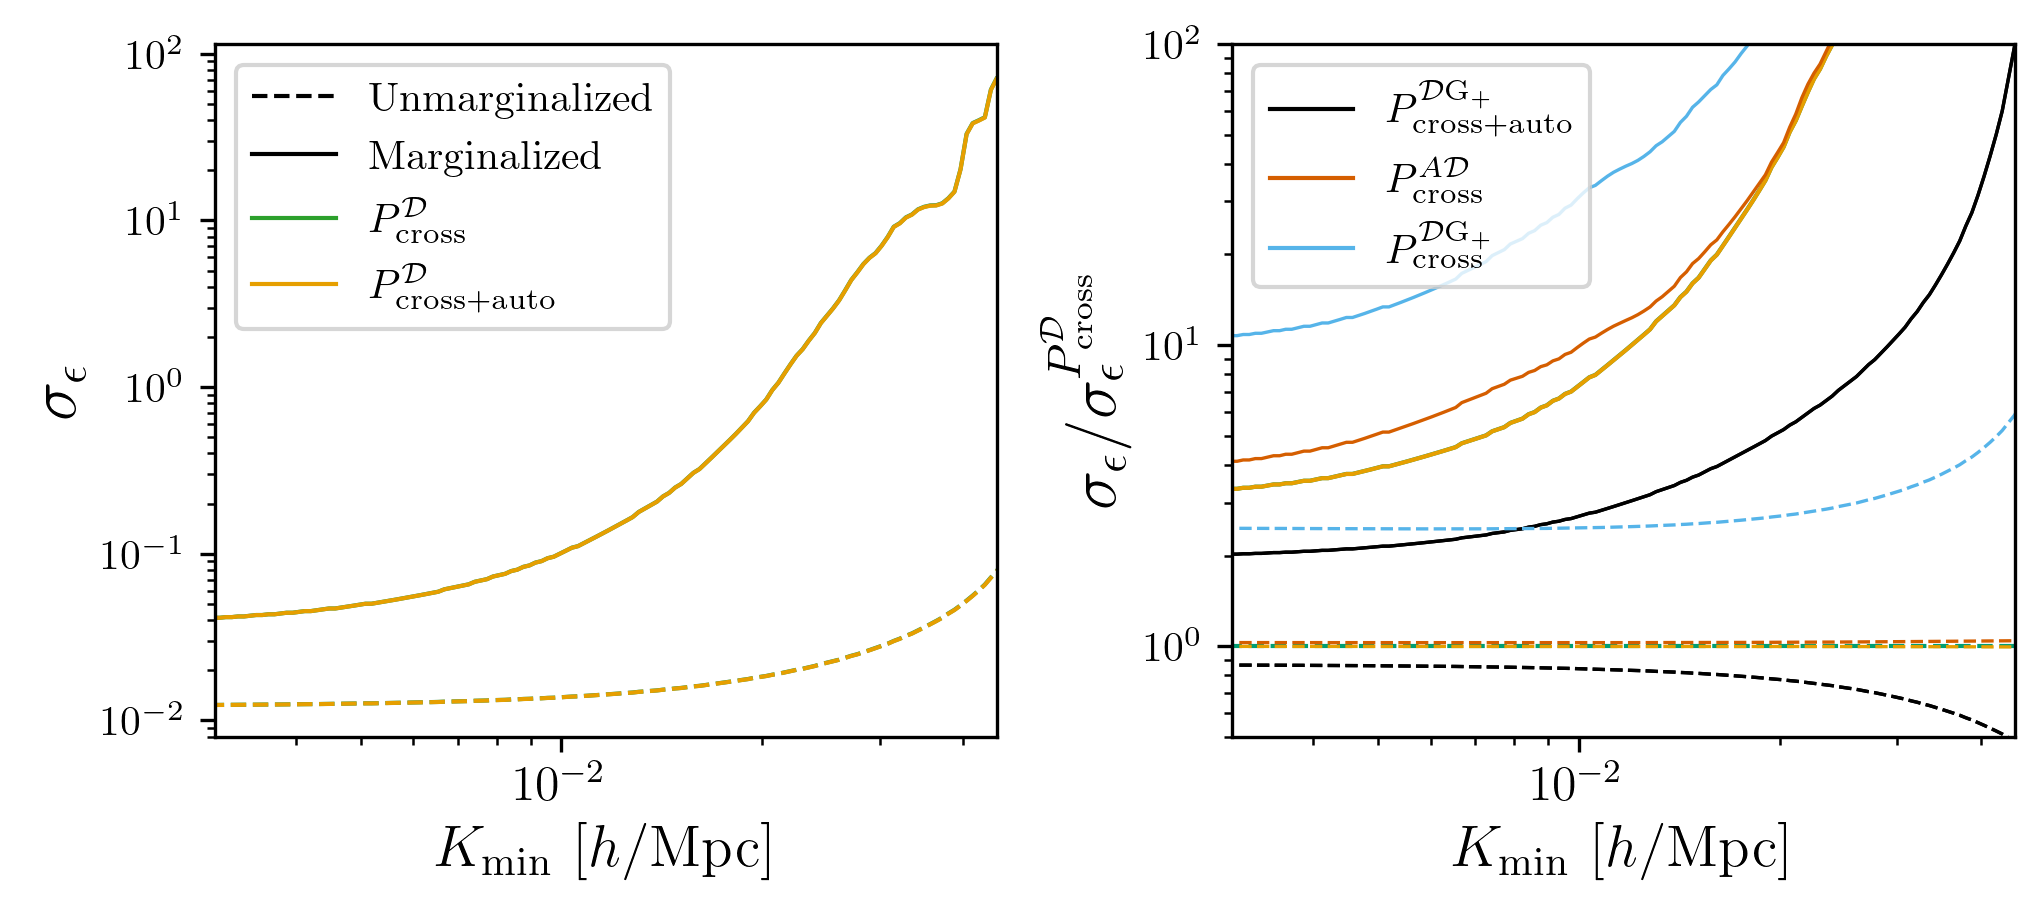

In [38]:
F_marg_plot(F_marg)

/tmp/ipykernel_17497/4257944458.py:120: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


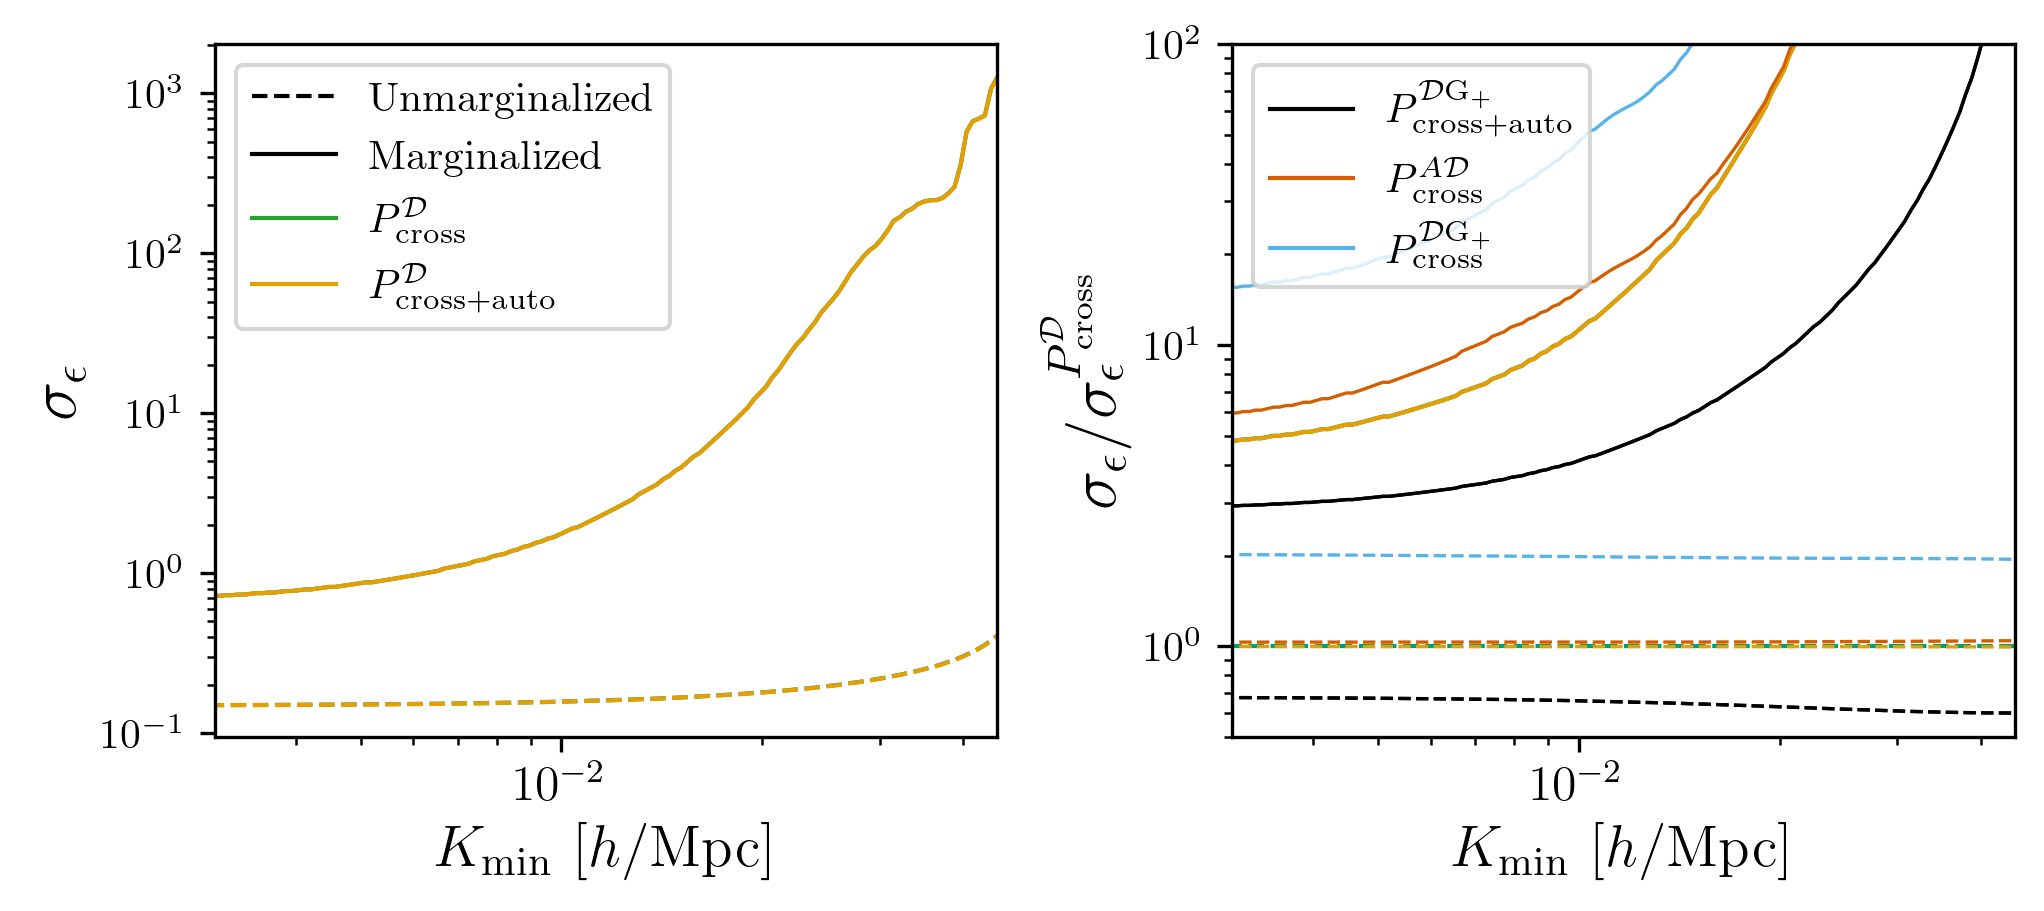

In [39]:
F_marg_plot(F_marg_realistic, title = "fisher_base_realistic")

In [40]:
F_marg[key_config].keys()

dict_keys(['F_AA_cross_base', 'F_cross_base', 'F_joint_base', 'F_cross', 'F_cross_full', 'F_joint', 'F_joint_full', 'F_joint_full_trace', 'F_joint_full_trace_A_only', 'F_joint_full_trace_growth_only', 'F_growth_joint_tr', 'F_joint_full_trace_growth_only_A_only', 'F_joint_with_growth', 'F_cross_with_growth', 'F_cross_base_growth', 'F_joint_base_growth', 'F_AA_cross_base_growth', 'F_RR_cross_base_growth'])

# Varying shot-noise

In [42]:
def ger_errors(Ks, FisherMatrix, selected, Kmin, Kmax, V, Narr = 50, method = 1):
    modes, F_int = fisher.get_integrated_fisher(Ks, FisherMatrix[:, selected][:, :, selected], Kmin = Kmin, Kmax = Kmax, V = V, Narr = Narr, method = method)
    err_matrix = jnp.array([jnp.diag(F_)**-0.5 for F_ in F_int])
    Cov_int_marg = [jnp.linalg.inv(F_) for F_ in F_int]
    err_marginalized_matrix = jnp.array([jnp.diag(C_)**0.5 for C_ in Cov_int_marg])
    return modes, err_matrix, err_marginalized_matrix, F_int, Cov_int_marg

In [69]:
def process_files_standard(v_fiducial):
    #k_min_analysis = 0.003
    
    k_min_analysis = 2*np.pi/V_MPC3**(1/3)
    
    from copy import deepcopy
    
    selected = list(range(7))#+[7, 8, 11, 12]
    Narr = 1
    
    out_results = {}
    nbars = []
    kmaxes = {}
    
    F_all = {}
    
    #marker_sizes = np.linspace(50, 100, len(kmax_indices))
    
    key = "n"
    
    conf_ok = []
    marker_size = []
    for i in range(1, 8):
        kmaxes[i] = []
        for jind, j in enumerate([3]):#kmax_indices [1, 2, 3, 4, 5]
        
            configuration_i = f'../../configs/abacus/desi_nbars/config_desi_base_{i}_{j}.yaml'
        
            with open(configuration_i, 'r') as f:
                config_i = yaml.safe_load(f)
    
            print(config_i["k_range"]["kmax"], config_i["number_density"]["nbar_A"]*3)
        
            name = config_i["name"]
            path = f"../../results/{name}/"
            #path = f"/users/odarwish/results/desi_base_asymm/"
            
            try:
                QR = qres.QEResults(config_i, relative_path = "../")
            except:
                print(i, j, "not found")
                continue
        
            conf_ok.append((i,j))
            #marker_size.append(marker_sizes[jind])
    
            print("INFO", config_i["number_density"]["nbar_A"]*3, config_i["k_range"]["kmax"])
    
            fac = 1
            fac_shot = 0.
            X_ = fore.Forecaster(configuration_i, shot_noise_A = fac, shot_noise_B = fac, variance_factor = fac, bispectrum_factor = fac_shot, trispectrum_factor = fac_shot)
    
            fac = 1e-5
            X_other = fore.Forecaster(configuration_i, shot_noise_A = fac, shot_noise_B = fac, variance_factor = fac, bispectrum_factor = fac_shot, trispectrum_factor = fac_shot)
    
            key_alt = None #"g"
            Fisher_results = X_.get_all_fisher(v_fiducial, X_.Ks, key, key_alt = key_alt, relative_path = "../.")
            
            F_all[(i,j)] = Fisher_results
            
            keys = ["g", "s", "t", "ga", "sa", "ta"]
            bias_per_mode = lambda v: fore.get_tot_bias(v, QR.get_get_norm()(key),  qres.get_normalization_array(key, keys, X_.Ks, QR.get_out_normalization_AB()))
            b_epsilon = jax.jacfwd(bias_per_mode)(v_fiducial)[:, 0]
            bias_per_mode = bias_per_mode(v_fiducial)
            
            CAA, CBB, CRR, CAB, CAR, CBR = X_other.get_functions(QR, "n", key2 = None)
            r2 = rho(CAA, CRR, CAR)**2
            
            analytical = (b_epsilon/bias_per_mode)**2*(2-r2)/(1-r2)
            analytical = analytical.reshape(-1, 1, 1)
            analytical_cross = 0.5*(b_epsilon/bias_per_mode)**2
            analytical_cross = analytical_cross.reshape(-1, 1, 1)
            analytical_cross_rr = (b_epsilon/bias_per_mode)**2*(2-r2)/(1-r2)
            analytical_cross_rr = analytical_cross_rr.reshape(-1, 1, 1)
    
            temp_results = {}
            for k, F in Fisher_results.items():
                modes, err, err_marg, F_int, F_int_marg = ger_errors(X_.Ks, F, selected, k_min_analysis, Kmax, V, Narr = Narr, method = method)
                modes, err_analytical_cross, _, F_int_analytical, F_int_marg = ger_errors(X_.Ks, analytical_cross, [0], k_min_analysis, Kmax, V, Narr = Narr, method = method)
                modes, err_analytical_joint, _, F_int_analytical, F_int_marg = ger_errors(X_.Ks, analytical_cross_rr, [0], k_min_analysis, Kmax, V, Narr = Narr, method = method)
                
                temp = {}
                temp["err"] = err
                temp["err_marg"] = err_marg
                temp["err_analytical_cross"] = err_analytical_cross
                temp["err_analytical_joint"] = err_analytical_joint
                temp_results[k] = temp
                
            temp_results["modes"] = modes
    
            out_results[(i, j)] = temp_results
    
            kmaxes[i].append(config_i["k_range"]["kmax"])
        
            print("Done", (i, j))
        nbars.append(3*config_i["number_density"]["nbar_A"])

    return nbars, kmaxes, out_results
        
    #plt.legend()
    #plt.show()
            

In [70]:
def process_files_optimal(v_fiducial):

    out_results_optimal = {}
    
    for i in range(1, 8):
        kmaxes[i] = []
        for jind, j in enumerate([3]):#kmax_indices
        
            configuration_i = f'../../configs/abacus/desi_nbars/config_desi_base_{i}_{j}_opt.yaml'
        
            with open(configuration_i, 'r') as f:
                config_i = yaml.safe_load(f)
    
            print(config_i["k_range"]["kmax"], config_i["number_density"]["nbar_A"]*3)
        
            name = config_i["name"]
            path = f"../../results/{name}/"
            #path = f"/users/odarwish/results/desi_base_asymm/"
            
            try:
                QR = qres.QEResults(config_i, relative_path = "../")
            except:
                print(i, j, "not found")
                continue
    
            fac = 1
            
            X_ = fore.Forecaster(configuration_i, shot_noise_A = fac, shot_noise_B = fac, variance_factor = fac, bispectrum_factor = 0, trispectrum_factor = 0)
    
            fac = 1e-5
            X_other = fore.Forecaster(configuration_i, shot_noise_A = fac, shot_noise_B = fac, variance_factor = fac, bispectrum_factor = fac_shot, trispectrum_factor = fac_shot)
    
            key_alt = "n"
            Fisher_results = X_.get_all_fisher(v_fiducial, X_.Ks, key, key_alt = key_alt, relative_path = "../.")
                    
            keys = ["g", "s", "t", "ga", "sa", "ta"]
            bias_per_mode = lambda v: fore.get_tot_bias(v, QR.get_get_norm()(key),  qres.get_normalization_array(key, keys, X_.Ks, QR.get_out_normalization_AB()))
            b_epsilon = jax.jacfwd(bias_per_mode)(v_fiducial)[:, 0]
            bias_per_mode = bias_per_mode(v_fiducial)
            
            CAA, CBB, CRR, CAB, CAR, CBR = X_other.get_functions(QR, "n", key2 = None)
            r2 = rho(CAA, CRR, CAR)**2
            
            analytical = (b_epsilon/bias_per_mode)**2*(2-r2)/(1-r2)
            analytical = analytical.reshape(-1, 1, 1)
            analytical_cross = 0.5*(b_epsilon/bias_per_mode)**2
            analytical_cross = analytical_cross.reshape(-1, 1, 1)
            analytical_cross_rr = (b_epsilon/bias_per_mode)**2*(2-r2)/(1-r2)
            analytical_cross_rr = analytical_cross_rr.reshape(-1, 1, 1)
    
            temp_results = {}
            for k, F in Fisher_results.items():
                modes, err, err_marg, F_int, F_int_marg = ger_errors(X_.Ks, F, selected, k_min_analysis, Kmax, V, Narr = Narr, method = method)
                modes, err_analytical_cross, _, F_int_analytical, F_int_marg = ger_errors(X_.Ks, analytical_cross, [0], k_min_analysis, Kmax, V, Narr = Narr, method = method)
                modes, err_analytical_joint, _, F_int_analytical, F_int_marg = ger_errors(X_.Ks, analytical_cross_rr, [0], k_min_analysis, Kmax, V, Narr = Narr, method = method)
                
                temp = {}
                temp["err"] = err
                temp["err_marg"] = err_marg
                temp["err_analytical_cross"] = err_analytical_cross
                temp["err_analytical_joint"] = err_analytical_joint
                temp_results[k] = temp
                
            temp_results["modes"] = modes
    
            out_results_optimal[(i, j)] = temp_results
        
            print("Done", (i, j))
        #nbars.append(3*config_i["number_density"]["nbar_A"])
        
    return out_results_optimal

In [65]:
Fisher_results.keys()

dict_keys(['F_AA_cross_base', 'F_cross_base', 'F_joint_base', 'F_cross', 'F_cross_full', 'F_joint', 'F_joint_full', 'F_joint_full_trace', 'F_joint_full_trace_A_only', 'F_joint_full_trace_growth_only', 'F_growth_joint_tr', 'F_joint_full_trace_growth_only_A_only', 'F_joint_with_growth', 'F_cross_with_growth', 'F_cross_base_growth', 'F_joint_base_growth', 'F_AA_cross_base_growth', 'F_RR_cross_base_growth'])

In [71]:
def plot_all(out_results, out_results_optimal, nbars, fname = "fisher_varying_nbar"):
    # import matplotlib.patches as mpatches
    
    def plot_specific(nbar, results, index, key, color, marker, plot_marge = False, alpha = 1, facecolors=None, edgecolors=None, label = None, s = 20):
        result_temp = results[key]
        
        err, err_marg = result_temp["err"], result_temp["err_marg"]    
        #print(err)
        if not plot_marge:
            p = plt.scatter(nbar, err[0, index], color = color, alpha = alpha, marker = marker, facecolors=facecolors, edgecolors=edgecolors, label = label, s = markersize)
        else:
            plt.scatter(nbar, err_marg[0, index], color = color, alpha = alpha, marker = marker, facecolors=facecolors, edgecolors=edgecolors, label = label, s = markersize)
    
    plot_marge = False
    index = 0
    
    colors = plot.COLORBLIND_PALETTE
    
    # fontsize of the tick labels
    
    plt.figure(figsize = (8, 5.))
    
    markersize = 80
    
    colors2 = plot.COLORBLIND_PALETTE_2
    ss = 2
    
    for i in range(1, 8):
        nbar_index = i-1
        for jind, j in enumerate([3]):
            
            #print(nbar_index, i, j, nbars[nbar_index], kmaxes[i][j-1])
            
            results = out_results[(i, j)]
            key_cross = "F_cross_base"
            #key_cross = "F_AA_cross_base"
            color = "red" if jind == 0 else "purple"
            marker = "s" #if jind == 0 else "X"
            plot_specific(nbars[nbar_index], results, index, key_cross, colors[1], marker, facecolors="none", edgecolors=colors[1], s = markersize)
    
            results_opt = out_results_optimal[(i, j)]
            marker_opt = "d"
            alpha_opt = 0.4
            plot_specific(nbars[nbar_index], results_opt, index, "F_cross_base", None, marker_opt, facecolors='none', edgecolors=colors[1])
            plot_specific(nbars[nbar_index], results_opt, index, "F_joint_base", None, marker_opt, facecolors='none', edgecolors=colors2[ss])
    
            #plt.scatter(nbars[nbar_index], results_opt[key_cross]["err_analytical_cross"][0, 0], marker = "o", facecolors='none', edgecolors="red")
            #plt.scatter(nbars[nbar_index], results_opt[key_cross]["err_analytical_joint"][0, 0], marker = "o", facecolors='none', edgecolors="black")
    
            plt.scatter(nbars[nbar_index], results_opt[key_cross]["err_analytical_cross"][0, 0], marker = "o", facecolors='none', edgecolors=colors[1], s = markersize)
            plt.scatter(nbars[nbar_index], results[key_cross]["err_analytical_joint"][0, 0], marker = "o", facecolors='none', edgecolors=colors2[ss], s = markersize)
    
            plt.scatter(nbars[nbar_index], results_opt[key_cross]["err_analytical_joint"][0, 0], marker = "o", facecolors='none', edgecolors="black", s = markersize)
    
            key_cross = "F_joint_full"
            #key_cross = "F_joint_full_trace_A_only"
            color = "green" if jind == 0 else "orange"
            marker = "s"
            plot_specific(nbars[nbar_index], results, index, key_cross, colors[2], marker, facecolors="none", edgecolors=colors2[ss], s = markersize)
    
    
    legend_elements = [ Line2D([0], [0], color="black", lw=lw, label=r"Base", 
                             marker="s", markerfacecolor='none', markeredgecolor='black', ls = ""),
                       Line2D([0], [0], color="black", lw=lw, label=r"Optimal", 
                             marker=marker_opt, markerfacecolor='none', markeredgecolor='black', ls = ""),
                       Line2D([0], [0], color="black", lw=lw, label=r"Very low noise limit", 
                             marker="o", markerfacecolor='none', markeredgecolor='black', ls = ""),
                      mpatches.Patch(facecolor='none', edgecolor=colors[1], label=r"$P^{A\mathcal{D}}_{\mathrm{cross}}$", ),
                      mpatches.Patch(facecolor='none', edgecolor=colors2[ss], label=r"$P^{A\mathcal{D}}_{\mathrm{cross+auto}}$", ),]
    
    plt.legend(handles=legend_elements, loc='best', fontsize=12, ncols = 2)
    
    colors = plot.COLORBLIND_PALETTE
    
    plt.vlines(5e-4, 1e-7, 2, color = colors[3], lw = 2)
    plt.vlines(5e-4*10, 1e-7, 2, color = colors[4], lw = 2)
    
    x, y = 5.55e-4, 4.e-2
    left, bottom = x, y
    plt.text(left, bottom, 'DESI-like',
            horizontalalignment='left', color = colors[3], fontsize = 14,
            verticalalignment='top')
    
    left, bottom = 10*x, y
    plt.text(left, bottom, 'Stage-V-like',
            horizontalalignment='left', color = colors[4], fontsize = 14,
            verticalalignment='top')
    
    
    plt.xticks(fontsize=18)     
    plt.yticks(fontsize=18) 
    
    #plt.ylim(1e-, 3e-4)
    plt.ylim(1e-7, 1)
    plt.xscale("log")
    plt.yscale("log")
    plt.ylabel(r'$\sigma_{\epsilon}$', fontsize = 22)
    plt.xlabel(r'$\bar{n}\ [h^3\mathrm{/Mpc^3]}$', fontsize=22)
    plt.title(r"$k_{\mathrm{max}}=0.23 h \mathrm{Mpc}^{-1}$")
    plt.savefig(f"figures/{fname}.pdf", dpi = 300, bbox_inches='tight')

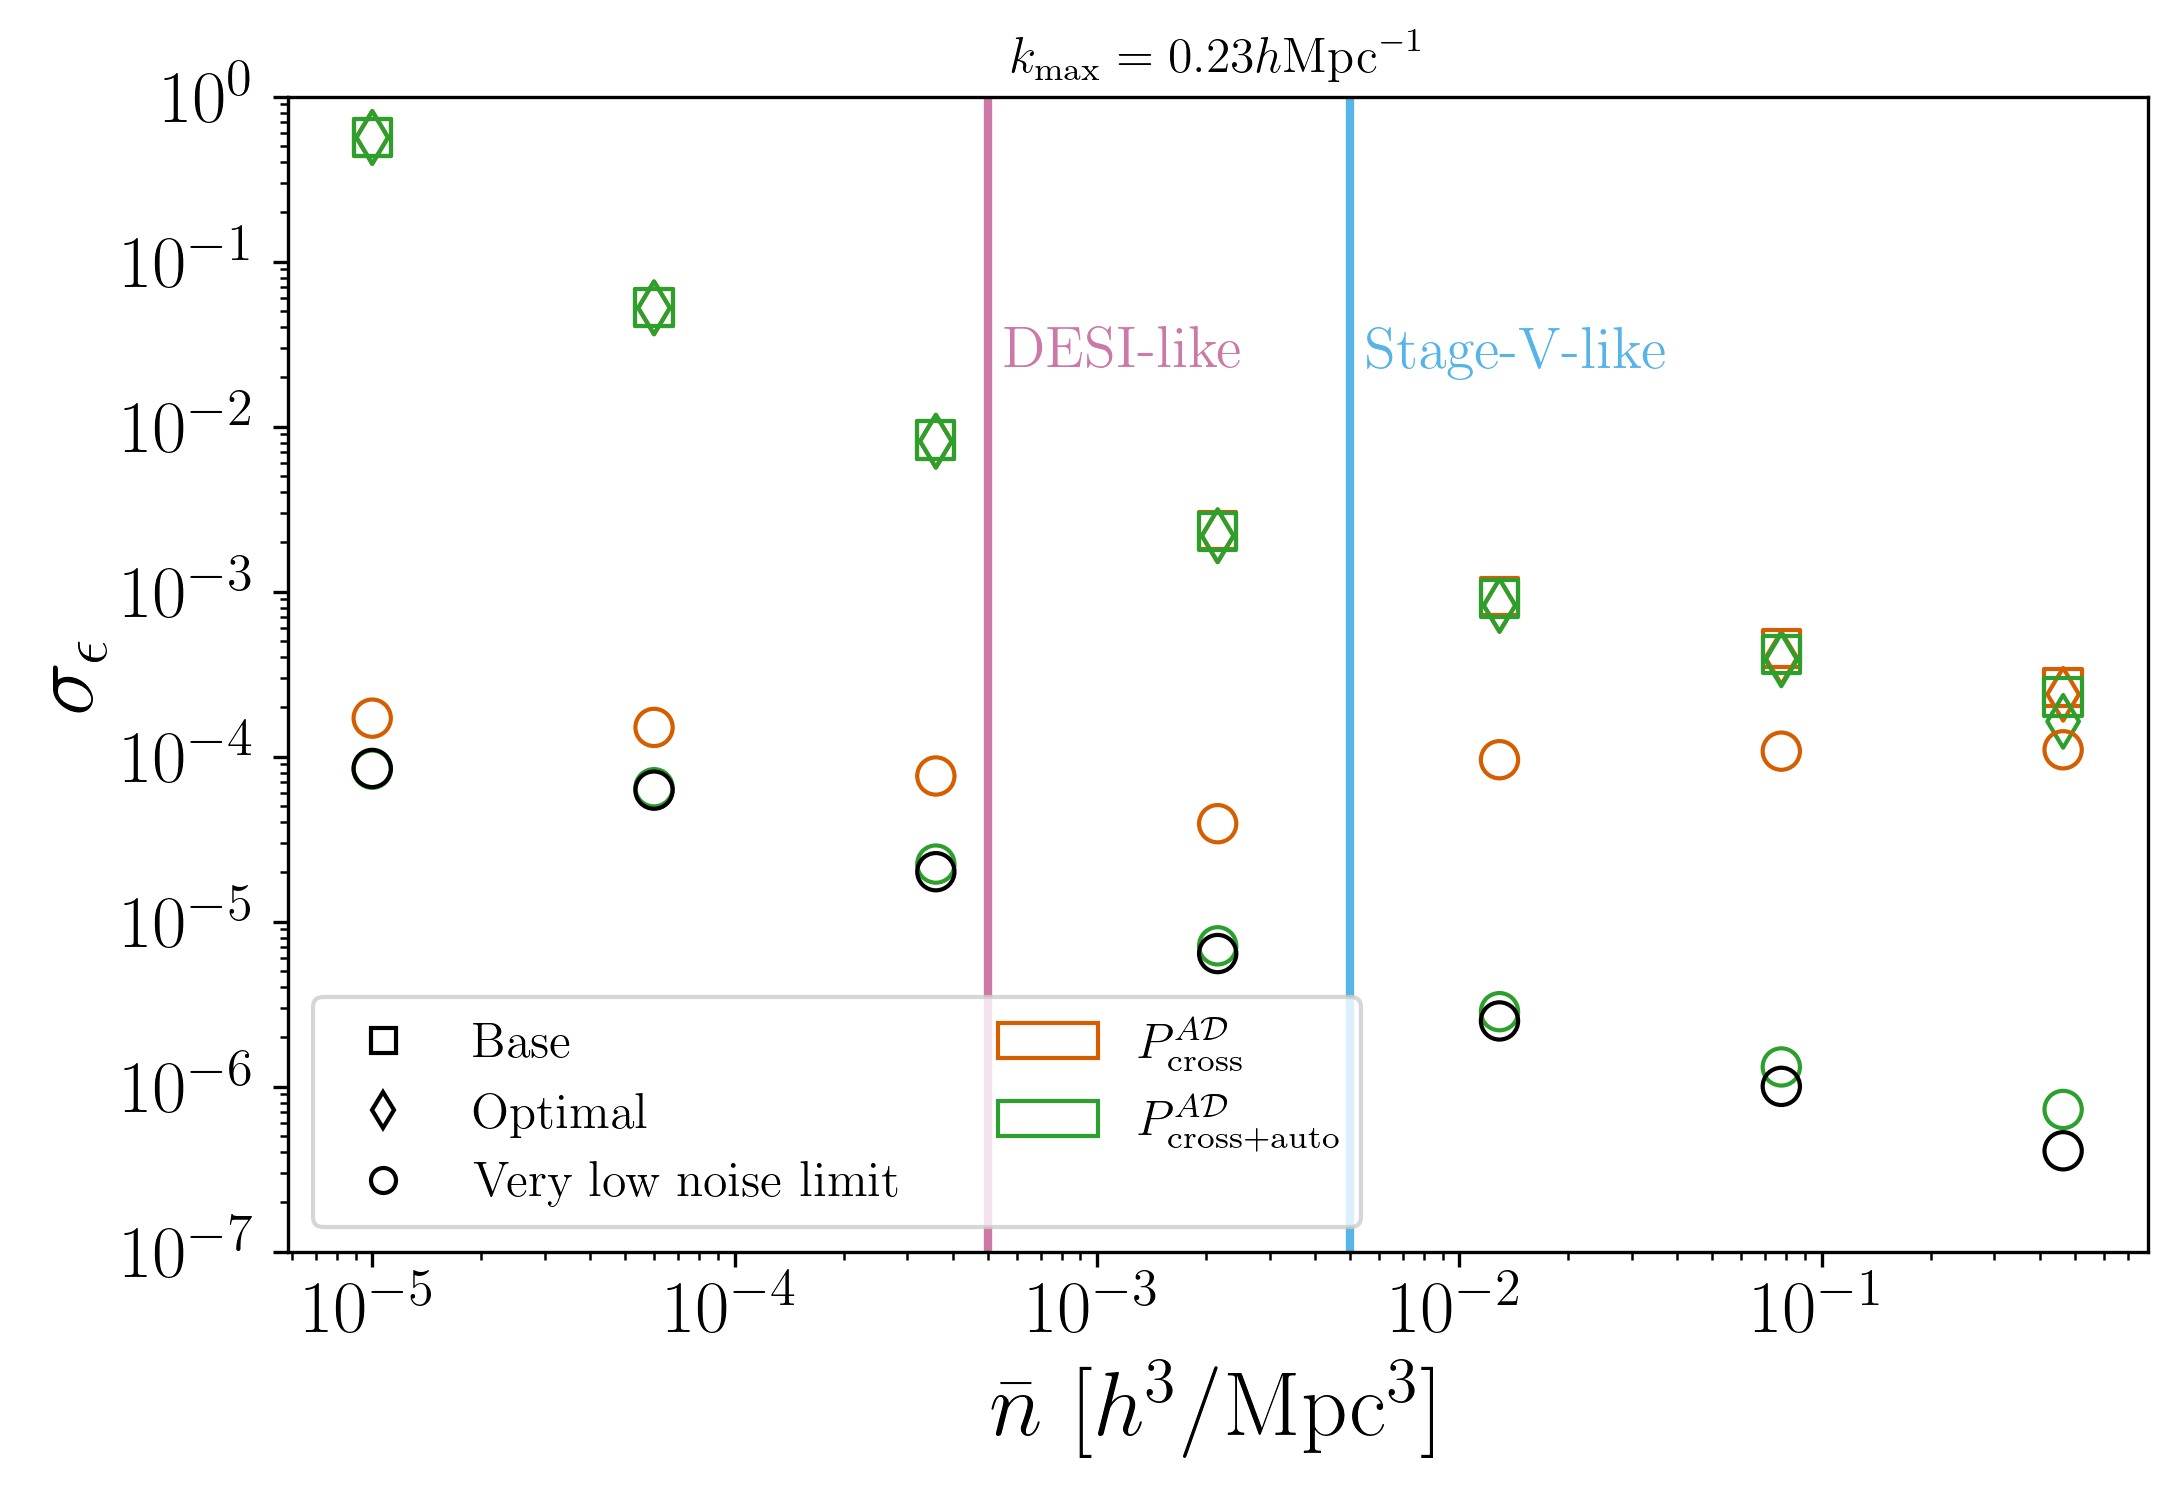

In [72]:
plot_all(out_results, out_results_optimal, nbars, fname = "fisher_varying_nbar")

In [73]:
nbars, kmaxes, out_results_real = process_files_standard(v_fiducial_realistic)
out_results_optimal_real = process_files_optimal(v_fiducial_realistic)

0.23333333333333334 1e-05
INFO 1e-05 0.23333333333333334
Done (1, 3)
0.23333333333333334 5.9948425031894096e-05
INFO 5.9948425031894096e-05 0.23333333333333334
Done (2, 3)
0.23333333333333334 0.00035938136638046257
INFO 0.00035938136638046257 0.23333333333333334
Done (3, 3)
0.23333333333333334 0.0021544346900318843
INFO 0.0021544346900318843 0.23333333333333334
Done (4, 3)
0.23333333333333334 0.01291549665014884
INFO 0.01291549665014884 0.23333333333333334
Done (5, 3)
0.23333333333333334 0.0774263682681127
INFO 0.0774263682681127 0.23333333333333334
Done (6, 3)
0.23333333333333334 0.4641588833612782
INFO 0.4641588833612782 0.23333333333333334
Done (7, 3)
0.23333333333333334 1e-05
Done (1, 3)
0.23333333333333334 5.9948425031894096e-05
Done (2, 3)
0.23333333333333334 0.00035938136638046257
Done (3, 3)
0.23333333333333334 0.0021544346900318843
Done (4, 3)
0.23333333333333334 0.01291549665014884
Done (5, 3)
0.23333333333333334 0.0774263682681127
Done (6, 3)
0.23333333333333334 0.4641588833

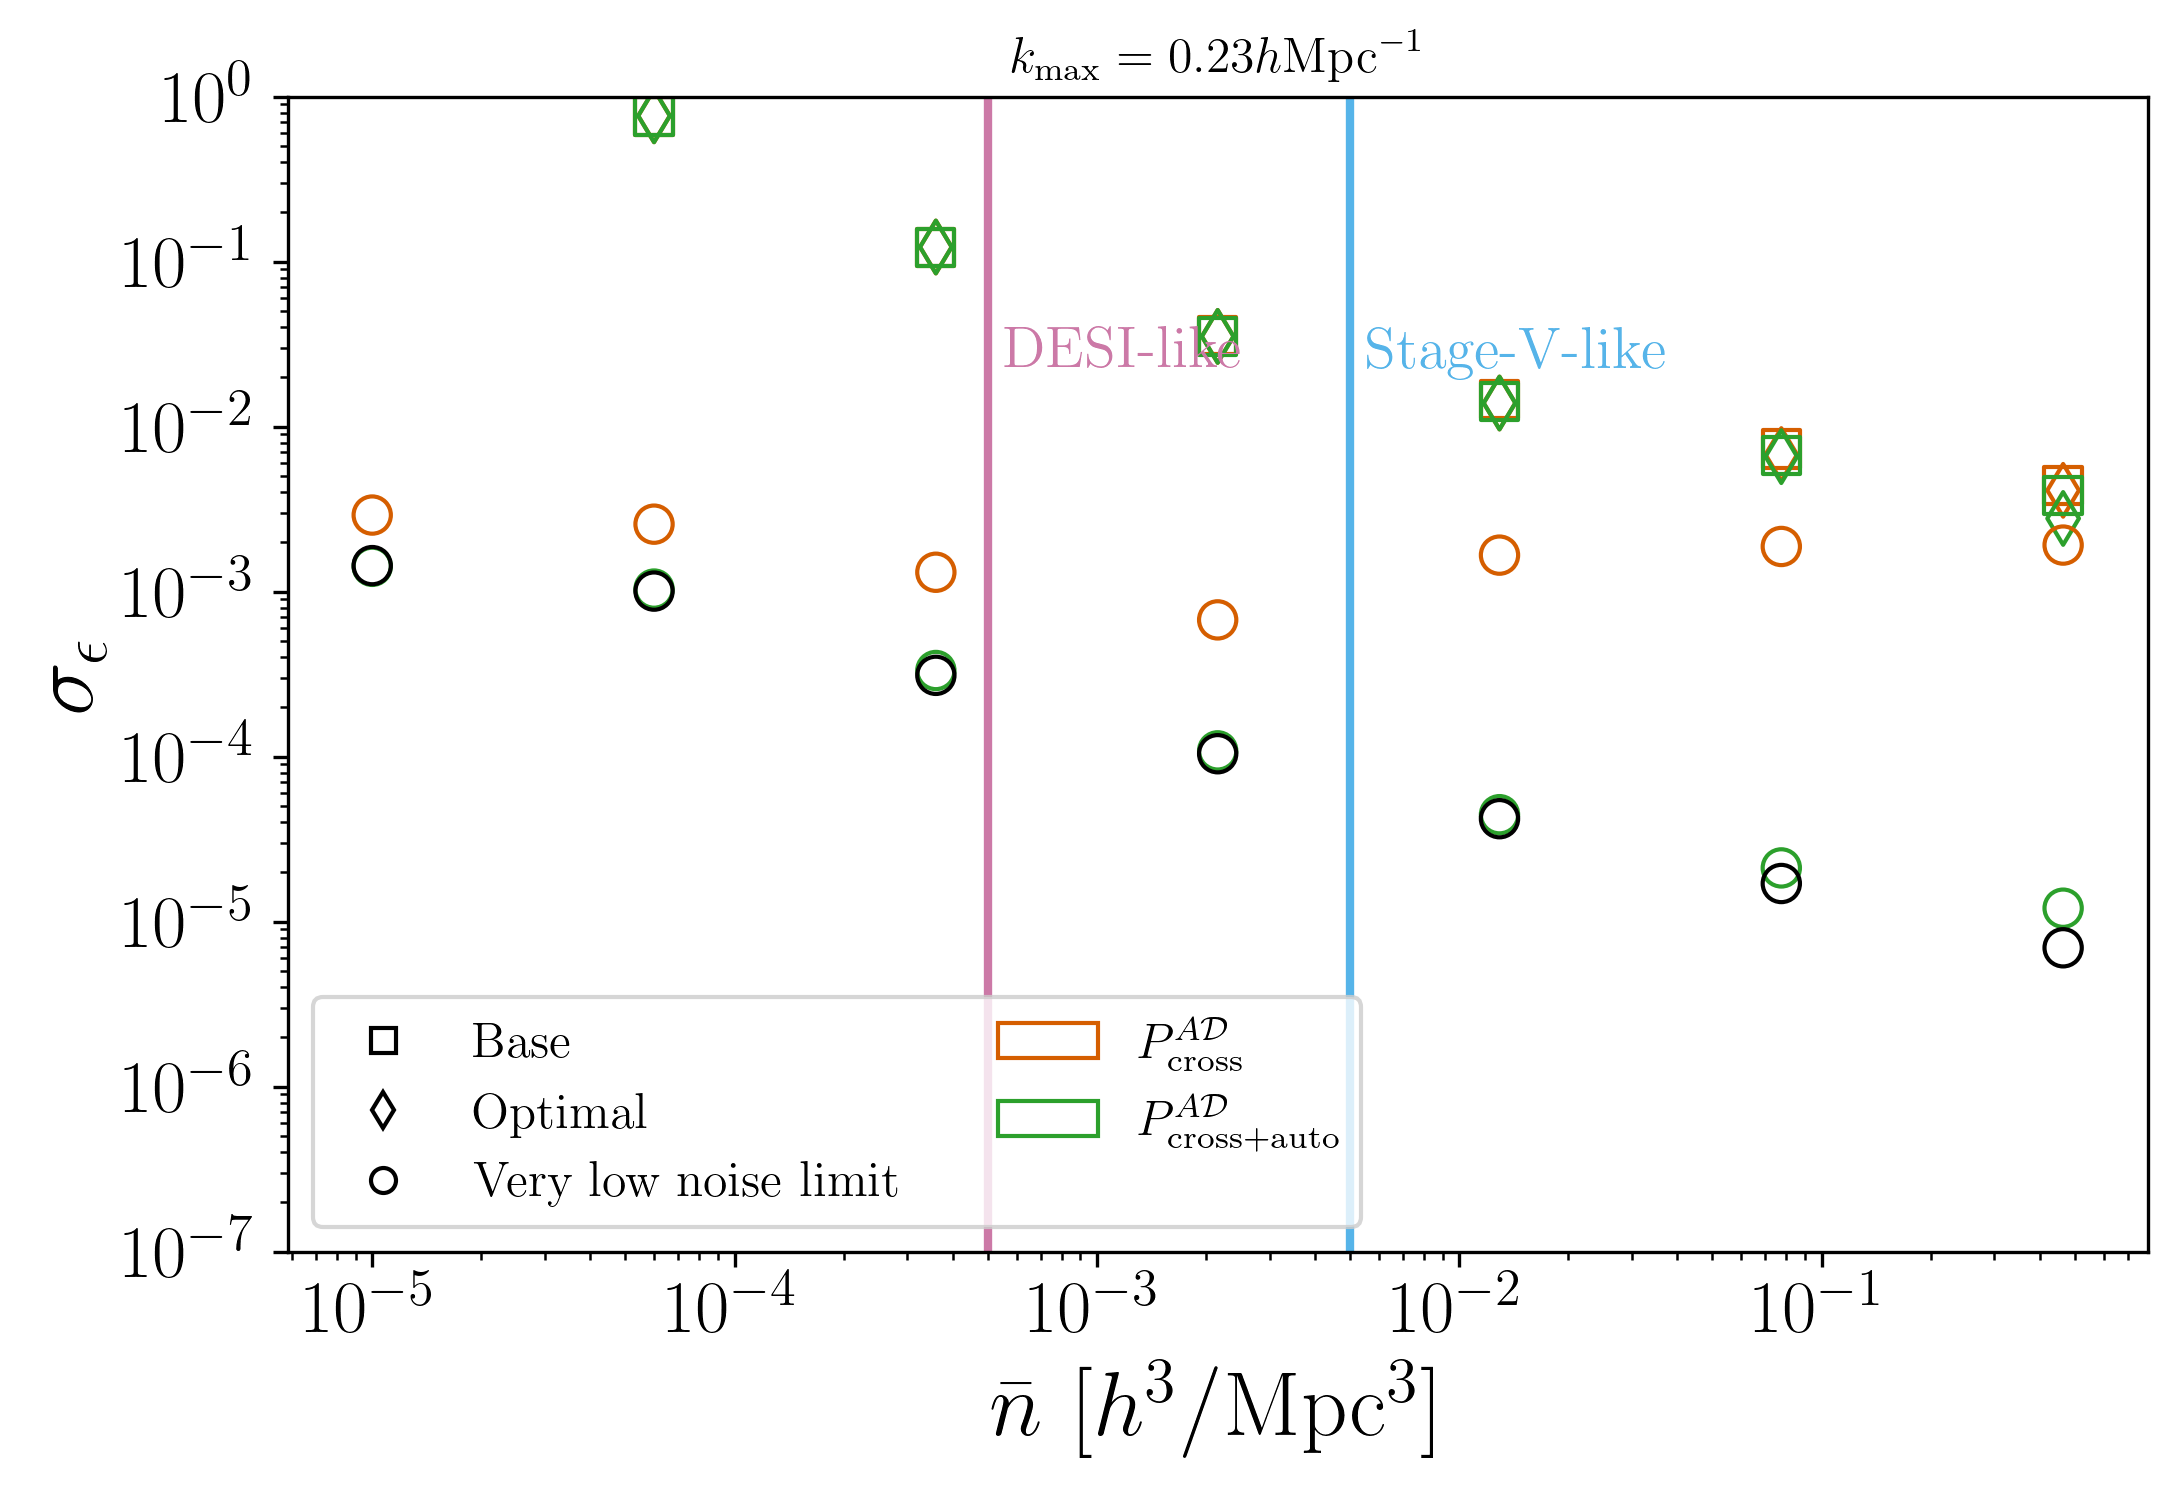

In [74]:
plot_all(out_results_real, out_results_optimal_real, nbars, fname = "fisher_varying_nbar_realistic")

In [ ]:
nbars = np.array(nbars)

keys = tuple(['modes', 'err_matrix', 'err_marginalized_matrix', 'err_matrix_cross', 'err_marginalized_matrix_cross'])

index = 0

argmin_nbar = np.argmin(abs(np.unique(nbars)-5e-4))
#then, for 0.15 h/Mpc is 
argmin_kmax = 1

#base_nbar_index = conf_ok[conf_ok.index((argmin_nbar+1, argmin_kmax+1))]
base_nbar_index = conf_ok[0]

results = out_results[base_nbar_index]

In [ ]:
results['err']

In [ ]:
nbars = np.array(nbars)

keys = tuple(['modes', 'err_matrix', 'err_marginalized_matrix', 'err_matrix_cross', 'err_marginalized_matrix_cross'])

index = 0

argmin_nbar = np.argmin(abs(np.unique(nbars)-5e-4))
#then, for 0.15 h/Mpc is 
argmin_kmax = 1

#base_nbar_index = conf_ok[conf_ok.index((argmin_nbar+1, argmin_kmax+1))]
base_nbar_index = conf_ok[0]

results = out_results[base_nbar_index]
modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]
base = err_matrix_cross[:, index]

k = 'err_matrix_cross'
errors_noise_cross_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])
k = 'err_marginalized_matrix_cross'
errors_marginalized_noise_cross_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])

k = 'err_matrix'
errors_noise_joint_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])
k = 'err_marginalized_matrix'
errors_marginalized_noise_joint_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])

In [ ]:
import matplotlib.cm as cm

index = 0

#nbar_1 = nbars[argmin] #
#nbar_2 = 1e-3 #
#nbar_3 = 0.33*nbar_1

from matplotlib.lines import Line2D

fig = plt.figure(figsize=plot.size, dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

color = lambda i: plot.COLORBLIND_PALETTE_2[i]

#ax.vlines(nbar_1, 1e-7, 2e3, color = color(6), ls = "--", lw = 2, alpha = 0.3)
#ax.vlines(nbar_2, 1e-7, 2e3, color = color(7), ls = "--", lw = 2, alpha = 0.3)
#ax.vlines(nbar_3, 1e-7, 2e3, color = color(7), ls = "--", lw = 2, alpha = 0.3)

n_kmax_points = len(kmax_indices)
colors_kmax = cm.viridis(np.linspace(0.2, 0.8, n_kmax_points))

i = 3
ax.scatter(nbars, errors_noise_cross_nbar, label = "Cross", color = color(i), marker = "+")#, s = marker_size)
ax.scatter(nbars, errors_noise_joint_nbar, label = "Joint", color = color(i), alpha = 0.5)#, s = marker_size)

i = 4
ax.scatter(nbars, errors_marginalized_noise_cross_nbar, label = "Cross Marg", color = color(i), marker = "+")
ax.scatter(nbars, errors_marginalized_noise_joint_nbar, label = "Joint Marg", color = color(i), alpha = 0.5)

#ax.scatter(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax, label = "Joint Marg Increasing $k_{\mathrm{max,rec}}$", color = color(5), alpha = 0.5)

  # or use cm.plasma, cm.coolwarm
#for i, (x, y) in enumerate(zip(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax)):
#    ax.scatter(x, y, color=colors_kmax[i], alpha=0.7)

#marker_sizes = np.linspace(50, 100, len(nbars_kmax))  # sizes increase with kmax
#ax.scatter(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax, 
#           s=marker_sizes, color=color(i), alpha=0.5)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel(r'$\sigma_{\epsilon}/\sigma_{\epsilon}^{\mathrm{Cross,unmarg.}}$', fontsize=14)
ax.set_xlabel(r'$\bar{n}\ [h^3\mathrm{/Mpc^3]}$', fontsize=14)

ax.legend(fontsize = 8)

ax.set_xlim(nbars.min()*(1-0.5), nbars.max()*(1+0.4))
ax.hlines(1, nbars.min()*(1-0.5), nbars.max()*(1+0.1), color = "black", lw = 2, alpha = 0.4)
#ax.set_xlim(5e-6, 2)
#ax.set_ylim(1e-5, 1e3)

plt.subplots_adjust(wspace=0.3)
fig.savefig(f"figures/fisher_varying_nbar.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()
plt.show()
plt.close()

## Comparing analytical with numerical results

In [67]:
def Fanalytical(efid, CAA, CAR, CRR, corr_coeff_factor = 1.):
    #this function can be generalized by just passing CAA, CAR, CRR in function of one var
    
    CAA_ = lambda e: CAA(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
    CAR_ = lambda e: CAR(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
    CRR_ = lambda e: CRR(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
    
    der_gg = jax.jacfwd(CAA_)(efid)
    gg = CAA_(efid)
    fgg = der_gg/gg
    
    der_gr = jax.jacfwd(CAR_)(efid)
    gr = CAR_(efid)
    fgr = der_gr/gr
    
    der_rr = jax.jacfwd(CRR_)(efid)
    rr = CRR_(efid)
    frr = der_rr/rr

    rc2 = gr**2/(gg*rr)*corr_coeff_factor

    A = fgg-2*rc2*fgr
    A = A**2
    B = 2*rc2*(1-rc2)*fgr**2
    C = 2*rc2*frr*(fgg-2*fgr)
    D = frr**2
    return (A+B+C+D)*1/2*1/(1-rc2)**2

In [68]:
mainkey = "n"

biases_dict = config["bias"]
number_density = config["number_density"]

nbar_A = number_density["nbar_A"]
nbar_B = number_density["nbar_B"]

b1A = biases_dict["b10_A"]
b1B = biases_dict["b10_B"]
e = 1e-3

b2A, b2B = -0.3, -0.3
bs2A, bs2B = biases.bs2_coev(b1A), biases.bs2_coev(b1B)
bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = 2, 1, 2, 1, 2, 1

vA = jnp.array([e*0., b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])  #fiducial point

QR = qres.QEResults(config, relative_path="../.")
responses_dict = QR.get_out_normalization_AB()
responses = qres.get_normalization_array(mainkey, ["g", "s", "t", "ga", "sa", "ta"], Ks, responses_dict)

keys = ["g", "s", "t", "ga", "sa", "ta"]

In [69]:
from qeep import fisher

shot_noise = 0.
variance_factor = 0.
bispectrum_factor = 0.
trispectrum_factor = 0.
asymm_shift = 1.
only_asymm_shift = 0.
growth_eps = 0.

vfid = None
fiducial_auto = False
fiducial_cross = False
fiducial_power = False

asymm_shift, only_asymm_shift = 1., 0.
bias_temp_function = lambda e: get_tot_bias(get_v(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])), QR.get_get_norm()(mainkey), responses, asymm_shift = asymm_shift, only_asymm_shift = only_asymm_shift)

In [73]:
CAA, CAR, CRR_with_var = get_functions_vA_only(*get_functions(
        QR,
        mainkey,
        shot_noise_A=shot_noise,
        variance_factor=1e-10,
        bispectrum_factor=bispectrum_factor,
        trispectrum_factor=trispectrum_factor,
        asymm_shift=asymm_shift,
        only_asymm_shift=only_asymm_shift,
        growth_eps=growth_eps,
    ))
    
O, Ovar = get_Ofuncs(CAA, CAR, CRR_with_var)

TypeError: get_functions_vA_only() takes 3 positional arguments but 6 were given

In [14]:
index = 0
e = 0.
derivative = jax.jacfwd(bias_temp_function)(e)
FF = 0.5*(derivative/bias_temp_function(e))**2
err_cross_analytical = FF**-0.5 #analytical cross-error
############
O, Ovar = get_Ofuncs(CAA, CAR, CRR_with_var)
F_cross = fisher.fisher_per_mode_single(vA, Ks, O, Ovar)
F_cross = jnp.nan_to_num(F_cross)[:, index, index]
err_cross_numerical = F_cross**-0.5 #numerical cross-error
############
FF_joint = Fanalytical(0., CAA, CAR, CRR_with_var)
err_joint_analytical = FF_joint**-0.5 #analytical joint-error
############
cov = get_cov(CAA, CAR, CRR_with_var)
F_joint = fisher.fisher_per_mode(vA, Ks, cov)[:, index, index]
err_joint_numerical = (F_joint**-0.5)
############ ALTERNATIVE NUMERICAL
cov_function = get_cov(CAA, CAR, CRR_with_var)
covf = lambda e: cov_function(Ks, jnp.array([e[0], b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
covariance = covf(jnp.array([0.]))
der_covariance = jax.jacfwd(covf)(jnp.array([0.]))
inv_covariance = jnp.linalg.inv(covariance)
inv_covariance = jnp.nan_to_num(inv_covariance, posinf = 0.)
FF_joint_code = jnp.einsum('kij,kjla,klm, kmib ->kab', inv_covariance, der_covariance, inv_covariance, der_covariance)*0.5
err_joint_numerical_alt = FF_joint_code[:, index, index]**-0.5 #0 index is e

############
FF_joint = Fanalytical(0., CAA, CAR, CRR_with_var, corr_coeff_factor = 0.)
err_joint_analytical_indep = FF_joint**-0.5 #analytical joint-error, but independent, cross-corr coeff r = 0

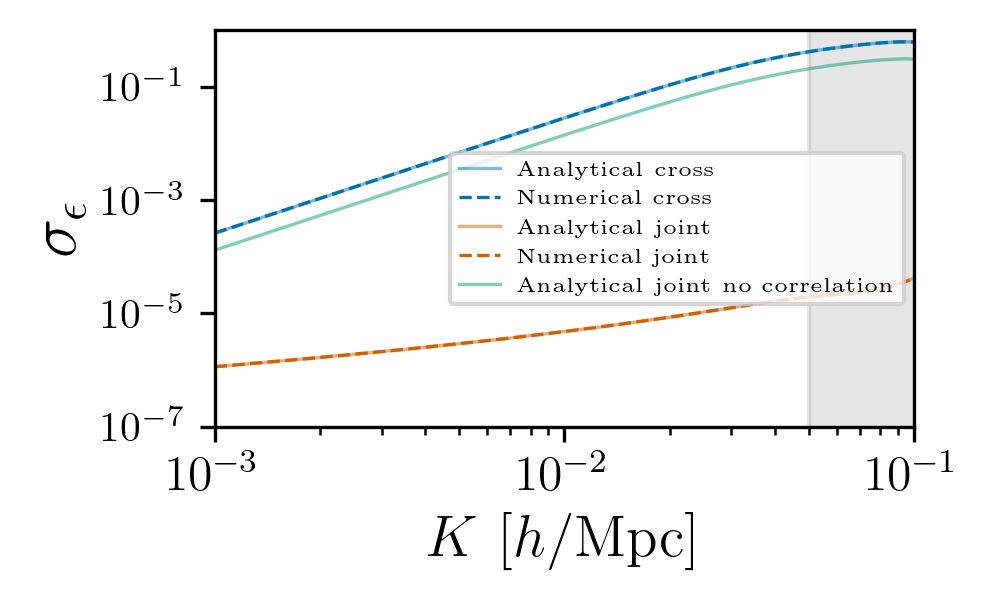

In [18]:
from matplotlib.lines import Line2D

fig = plt.figure(figsize=plot.size, dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig)#, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

ax.loglog(Ks, err_cross_analytical, label = "Analytical cross", alpha = 0.5, color = plot.COLORBLIND_PALETTE[0])
ax.loglog(Ks, err_cross_numerical, label = "Numerical cross", ls = "--", color = plot.COLORBLIND_PALETTE[0])

ax.loglog(Ks, err_joint_analytical, label = "Analytical joint", alpha = 0.5, color = plot.COLORBLIND_PALETTE[1])
ax.loglog(Ks, err_joint_numerical, label = "Numerical joint", ls = "--", color = plot.COLORBLIND_PALETTE[1])

ax.loglog(Ks, err_joint_analytical_indep, label = "Analytical joint no correlation", alpha = 0.5, color = plot.COLORBLIND_PALETTE[2])

ax.fill_betweenx([0, 1], 5e-2, 0.15, color = "black", alpha = 0.1)

ax.legend(fontsize = 5, loc = "best")
ax.set_xlim(1e-3, 1e-1)
ax.set_ylim(1e-7, 1)
ax.set_xlabel(r'$K \ [h/\mathrm{Mpc}]$', fontsize=14)
ax.set_ylabel(r'$\sigma_{\epsilon}$', fontsize=16)

fig.savefig(f"figures/fisher_analytical.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()
plt.show()
plt.close()

## Full exploration

In [19]:
from qeep import fisher

vA = jnp.array([0*e, b1A, b2A, bs2A, bGXA*0, bGXB*0, bSXA*0, bSXB*0, bTXA*0, bTXB*0]) #fiducial point

vA = jnp.array([1e-9, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]) #fiducial point


mainkey = mainkey
QR = QR

shot_noise = 0.
variance_factor = 1
bispectrum_factor = 0.
trispectrum_factor = 0.
asymm_shift = 1.
only_asymm_shift = 0.
growth_eps = 0.

vfid = None
fiducial_auto = False
fiducial_cross = False
fiducial_power = False

<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_41404/3707633185.py:3: SyntaxWarning: invalid escape sequence '\e'
  labels = ["$\epsilon$", "$b_1$", "$b_2$"]


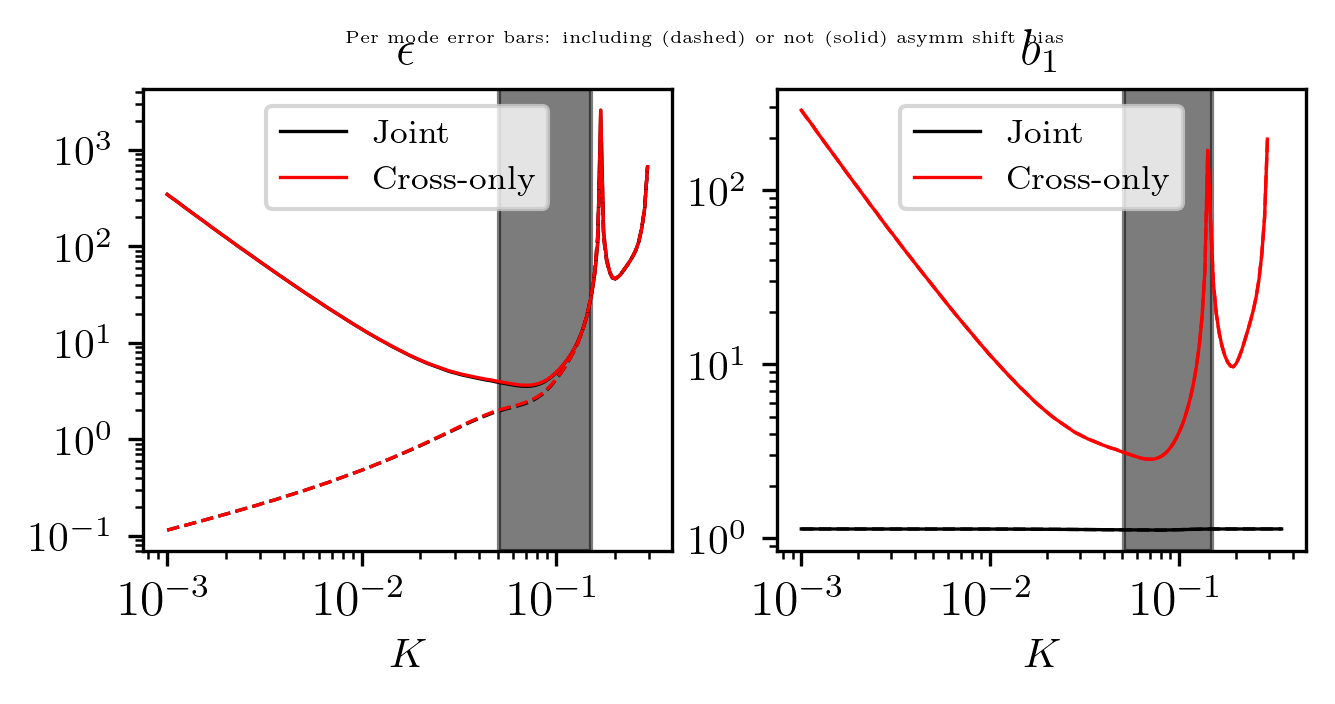

In [20]:
indices = [0, 1]
fig, axs = plt.subplots(1, len(indices), figsize=(5, 2), dpi=plot.DPI, facecolor='white')
labels = ["$\epsilon$", "$b_1$", "$b_2$"]

fig.suptitle("Per mode error bars: including (dashed) or not (solid) asymm shift bias", fontsize = 4)

for index_case, asymm_shift in enumerate([0, 1]):
    
    CAA, CAR, CRR = get_functions_vA_only(*get_functions(
        mainkey,
        QR,
        shot_noise=shot_noise,
        variance_factor=variance_factor,
        bispectrum_factor=bispectrum_factor,
        trispectrum_factor=trispectrum_factor,
        asymm_shift=asymm_shift,
        only_asymm_shift=only_asymm_shift,
        growth_eps=growth_eps,
        vfid=vfid,
        fiducial_auto=fiducial_auto,
        fiducial_cross=fiducial_cross,
        fiducial_power=fiducial_power
    ))
    
    cov = get_cov(CAA, CAR, CRR)
    O, Ovar = get_Ofuncs(CAA, CAR, CRR)
    
    F_single = fisher.fisher_per_mode_single(vA, Ks, O, Ovar)
    F_single = jnp.nan_to_num(F_single)
    
    F = fisher.fisher_per_mode(vA, Ks, cov)


    for i, index in enumerate(indices):
        ax = axs[i]
        ax.set_title(labels[i])
        ax.loglog(Ks, F[:, index, index]**-0.5, label = "Joint" if index_case == 0 else None, color = "black", ls = "-" if index_case == 0 else "--")
        ax.loglog(Ks, F_single[:, index, index]**-0.5, color = "red", label = "Cross-only" if index_case == 0 else None, ls = "-" if index_case == 0 else "--")
        ax.set_xlabel("$K$")
        #ax.set_xlim(1e-3, 1e-1)
        #ax.set_ylim(1e-6)
        ax.axvspan(QR.kmin, QR.kmax, alpha=0.3, color = 'black')
        ax.legend()
#fig.tight_layout()

## Paper results

In [21]:
def get_integrated_fisher(K_array, F, Kmin = 0.001, Kmax = 0.05, V = 1, Narr = 20):
    
    err_ms, err_us = [], []
    
    Kmaxarr = min(0.2, Kmax)
    modes = jnp.logspace(np.log10(Kmin), np.log10(Kmaxarr), Narr) if Narr > 1 else [Kmin]

    F_int = []
    for KK in modes:
        F_int.append(fisher.get_F_integrated_fast(K_array, F, KK, Kmax, V = V, N = 999))
        
    return modes, F_int

In [77]:
Kmax = 5e-2
def ger_errors(fisher, selected, Kmin, Kmax, V, Narr = 50, return_Fint = False):
    modes, F_int = get_integrated_fisher(Ks, fisher[:, selected][:, :, selected], Kmin = Kmin, Kmax = Kmax, V = V, Narr = Narr)
    err_matrix = jnp.array([jnp.diag(F_)**-0.5 for F_ in F_int])
    err_marginalized_matrix = jnp.array([jnp.diag(jnp.linalg.inv(F_))**0.5 for F_ in F_int])
    if not return_Fint:
        return modes, err_matrix, err_marginalized_matrix
    else:
        return modes, err_matrix, err_marginalized_matrix, F_int

In [23]:
from qeep import fisher

#vA = jnp.array([0*e, b1A, b2A, bs2A, bGXA*0, bGXB*0, bSXA*0, bSXB*0, bTXA*0, bTXB*0]) #fiducial point

def get_spectra_info(mainkey, QR, e, shot_noise, variance_factor, bispectrum_factor, trispectrum_factor, asymm_shift, only_asymm_shift, growth_eps):
    
    vA = jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]) #fiducial point
        
    vfid = None
    fiducial_auto = False
    fiducial_cross = False
    fiducial_power = False
        
    CAA, CAR, CRR = get_functions_vA_only(*get_functions(
            mainkey,
            QR,
            shot_noise=shot_noise,
            variance_factor=variance_factor,
            bispectrum_factor=bispectrum_factor,
            trispectrum_factor=trispectrum_factor,
            asymm_shift=asymm_shift,
            only_asymm_shift=only_asymm_shift,
            growth_eps=growth_eps,
            vfid=vfid,
            fiducial_auto=fiducial_auto,
            fiducial_cross=fiducial_cross,
            fiducial_power=fiducial_power
        ))
        

    return vA, CAA, CAR, CRR
    
def get_full_fisher(mainkey, QR, e, shot_noise, variance_factor, bispectrum_factor, trispectrum_factor, asymm_shift, only_asymm_shift, growth_eps, r2 = False):
    
    vA, cov, O, Ovar = get_spectra_info(mainkey, QR, e, shot_noise, variance_factor, bispectrum_factor, trispectrum_factor, asymm_shift, only_asymm_shift, growth_eps)
        
    cov = get_cov(CAA, CAR, CRR)
    O, Ovar = get_Ofuncs(CAA, CAR, CRR)
    
    F_cross = fisher.fisher_per_mode_single(vA, Ks, O, Ovar)
    F_cross = jnp.nan_to_num(F_cross)
    
    F_joint = fisher.fisher_per_mode(vA, Ks, cov)

    if not r2:
        return F_cross, F_joint
    else:
        gr = CAR(vA)
        rr = CRR(vA)
        gg = CAA(vA)
        r2 = gr**2/(gg*rr)
        return F_cross, F_joint, r2

In [24]:
from copy import deepcopy

configurations = {}

configuration_base = {"mainkey": "n",
                      "QR": QR,
                      "e": 0.,
                      "shot_noise": 1/nbar_A, 
                      "variance_factor": 1., 
                      "bispectrum_factor": 0., 
                      "trispectrum_factor": 0., 
                      "asymm_shift": 1., #include asymm shift term or not. If 0, use only G, T asymm
                      "only_asymm_shift": 0., #only include asymm shift term or not, If 1, use only S asymm
                      "growth_eps": 0., #enhanced growth for galaxy clustering
                     }

configuration_no_shot = deepcopy(configuration_base)
configuration_no_shot["shot_noise"] = 0.

configuration_no_noise = deepcopy(configuration_base)
configuration_no_noise["shot_noise"] = 0.
configuration_no_noise["variance_factor"] = 1e-4

configuration_growth_no_noise = deepcopy(configuration_base)
configuration_no_noise["shot_noise"] = 0.
configuration_no_noise["variance_factor"] = 1e-4
configuration_no_noise["growth_eps"] = 1.

configuration_growth = deepcopy(configuration_base)
configuration_growth["growth_eps"] = 1.

configuration_only_asymm = deepcopy(configuration_base)
configuration_only_asymm["only_asymm_shift"] = 1.

configuration_all_shot = deepcopy(configuration_base)
configuration_all_shot["bispectrum_factor"] = 1.
configuration_all_shot["trispectrum_factor"] = 1.

configurations["base"] = configuration_base
#configurations["no_shot_noise"] = configuration_no_shot
#configurations["no_noise"] = configuration_no_noise
#configurations["growth_eps"] = configuration_growth
#configurations["growth_eps_no_noise"] = configuration_growth_no_noise
configurations["only_asymm_shift"] = configuration_only_asymm
#configurations["all_shot_noise"] = configuration_all_shot

In [25]:
#import jax
#gpus = jax.devices('gpu')
#import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Only GPU 1 will be visible to JAX

In [26]:
h = 0.67
V = 5  #100*h**3 #in Gpc h^{-3}
V_MPC3 = V*1e9
k_min_analysis = 2*np.pi/V_MPC3**(1/3)
print(k_min_analysis)

0.0036744290581343145


In [27]:
selected = [0, 1, 2, 3]#, 4, 5, 6]
Narr = 70

out_results = {}
for k, conf in configurations.items():
    F_cross, F_joint = get_full_fisher(**conf)
    modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross, err_marginalized_matrix_cross = ger_errors(F_cross, selected, k_min_analysis, Kmax, V, Narr = Narr)
    out_results[k] = {"modes": modes, "err_matrix": err_matrix, "err_marginalized_matrix": err_marginalized_matrix, "err_matrix_cross": err_matrix_cross, "err_marginalized_matrix_cross": err_marginalized_matrix_cross}
    out_results[k]["F_joint"] = F_joint
    out_results[k]["F_cross"] = F_cross
    print("Done", k)

selected_alt = [0, 1]#, 4, 5, 6]
out_results_alt = {}
for k, conf in configurations.items():
    F_cross, F_joint = get_full_fisher(**conf)
    modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected_alt, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross, err_marginalized_matrix_cross = ger_errors(F_cross, selected_alt, k_min_analysis, Kmax, V, Narr = Narr)
    out_results_alt[k] = {"modes": modes, "err_matrix": err_matrix, "err_marginalized_matrix": err_marginalized_matrix, "err_matrix_cross": err_matrix_cross, "err_marginalized_matrix_cross": err_marginalized_matrix_cross}
    out_results_alt[k]["F_joint"] = F_joint
    out_results_alt[k]["F_cross"] = F_cross
    print("Done", k)

Done base
Done only_asymm_shift
Done base
Done only_asymm_shift


In [28]:
F_cross, F_joint, r2 = get_full_fisher(**configurations["only_asymm_shift"], r2 = True)
modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected, k_min_analysis, Kmax, V, Narr = Narr)

In [29]:
vA, CAA, CAR, CRR = get_spectra_info(**configurations["only_asymm_shift"])

In [30]:
#plt.plot(Ks, r2)
#plt.plot(Ks, CAR(vA)**2/(CAA(vA)*CRR(vA)), ls = "--")

In [31]:
P_AA = CAA(vA)
P_AR = CAR(vA)
P_RR = CRR(vA)

CAA_ = lambda e: CAA(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
CAR_ = lambda e: CAR(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))
CRR_ = lambda e: CRR(jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]))

efid = jnp.array([0.])[0]
der_AA = jax.jacfwd(CAA_)(efid)
der_AR = jax.jacfwd(CAR_)(efid)
der_RR = jax.jacfwd(CRR_)(efid)

def compute_fisher_aa(P_AA, P_AR, P_RR, der_AA, der_AR, der_RR, rfactor = 1.):
    """
    Compute Fisher matrix element F_aa using equation (52)
    
    Parameters:
    -----------
    P_AA, P_AR, P_RR : power spectrum values
    der_AA, der_AR, der_RR : derivatives of power spectra w.r.t. parameter a
    """
    
    # Compute correlation coefficient r_cc^2
    r2 = P_AR**2 / (P_AA * P_RR) * rfactor
    r_cc = jnp.sqrt(r2)
    
    # Compute normalized derivatives
    norm_der_AA = der_AA / P_AA
    norm_der_AR = der_AR / P_AR
    norm_der_RR = der_RR / P_RR
    
    # First term: (∂_a P^gg/P^gg - 2r_cc^2 ∂_a P^gr/P^gr)^2
    term1 = (norm_der_AA - 2*r2*norm_der_AR)**2
    
    # Second term: 2r_cc^2(1-r_cc^2)(∂_a P^gr/P^gr)^2
    term2 = 2*r2*(1 - r2)*(norm_der_AR)**2
    
    # Third term: 2r_cc^2 (∂_a P^rr/P^rr)(∂_a P^gg/P^gg - 2∂_a P^gr/P^gr)
    term3 = 2*r2*norm_der_RR*(norm_der_AA - 2*norm_der_AR)
    
    # Fourth term: (∂_a P^rr/P^rr)^2
    term4 = norm_der_RR**2
    
    # Combine all terms
    numerator = term1 + term2 + term3 + term4
    denominator = 2*(1 - r2)**2
    
    F_aa = numerator / denominator
    
    return F_aa

In [32]:
r2 = P_AR**2/(P_AA*P_RR)

F_joint_analytical = 0.5*1/(1-r2)**2*((der_AA*0./P_AA)**2+(der_RR*0./P_RR)**2+2*r2*(1-r2)*(der_AR/P_AR)**2)

F_joint_aa = compute_fisher_aa(P_AA, P_AR, P_RR, der_AA, der_AR, der_RR, rfactor = 1.)

F_cross_analytical = ((der_AR)**2/(P_AA*P_RR+P_AR**2))

## Cosmic variance cancellation

In [24]:
from copy import deepcopy

configurations_noise = {}

QR = qres.QEResults(config)

configuration_base = {"mainkey": "n",
                      "QR": QR,
                      "e": 0.,
                      "shot_noise": 1/config["number_density"]["nbar_A"], 
                      "variance_factor": 1., 
                      "bispectrum_factor": 0., 
                      "trispectrum_factor": 0., 
                      "asymm_shift": 1., #include asymm shift term or not. If 0, use only G, T asymm
                      "only_asymm_shift": 0., #only include asymm shift term or not, If 1, use only S asymm
                      "growth_eps": 0., #enhanced growth for galaxy clustering
                     }

N = 30
cases = [f"noise_{i}" for i in range(N)]
factors = np.array([np.exp(i)*1e-8 for i in range(N)])

factors = np.append(factors, 1)
cases.append(f"base")

for i, case in enumerate(cases):
    config_temp = deepcopy(configuration_base)
    config_temp["shot_noise"] *= factors[i]
    config_temp["variance_factor"] *= factors[i]
    configurations_noise[i] = config_temp

In [25]:
h = 0.67
V = 5  #100*h**3 #in Gpc h^{-3}
V_MPC3 = V*1e9
k_min_analysis = 2*np.pi/V_MPC3**(1/3)

##vA = jnp.array([0*e, b1A, b2A, bs2A, bGXA*0, bGXB*0, bSXA*0, bSXB*0, bTXA*0, bTXB*0]) #fiducial point
selected = [0, 1, 2, 3]#, 4, 5, 6]
selected_extended = [0, 1, 2, 3, 4, 5] #, 8, 9]
Narr = 1

out_results = {}
for k, conf in configurations_noise.items():
    F_cross, F_joint = get_full_fisher(**conf)
    modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross, err_marginalized_matrix_cross = ger_errors(F_cross, selected, k_min_analysis, Kmax, V, Narr = Narr)

    modes, err_matrix_extended, err_marginalized_matrix_extended = ger_errors(F_joint, selected_extended, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross_extended, err_marginalized_matrix_cross_extended = ger_errors(F_cross, selected_extended, k_min_analysis, Kmax, V, Narr = Narr)

    temp_res = {"modes": modes, "err_matrix": err_matrix, "err_marginalized_matrix": err_marginalized_matrix, "err_matrix_cross": err_matrix_cross, "err_marginalized_matrix_cross": err_marginalized_matrix_cross}

    temp_res["err_matrix_extended"] = err_matrix_extended
    temp_res["err_marginalized_matrix_extended"] = err_marginalized_matrix_extended
    temp_res["err_matrix_cross_extended"] = err_matrix_cross_extended
    temp_res["err_marginalized_matrix_cross_extended"] = err_marginalized_matrix_cross_extended
    
    out_results[factors[k]] = temp_res
    out_results[factors[k]]["F_joint"] = F_joint
    out_results[factors[k]]["F_cross"] = F_cross
    print("Done", k)

Done 0
Done 1
Done 2
Done 3
Done 4
Done 5
Done 6
Done 7
Done 8
Done 9
Done 10
Done 11
Done 12
Done 13
Done 14
Done 15
Done 16
Done 17
Done 18
Done 19
Done 20
Done 21
Done 22
Done 23
Done 24
Done 25
Done 26
Done 27
Done 28
Done 29
Done 30


In [26]:
keys = tuple(['modes', 'err_matrix', 'err_marginalized_matrix', 'err_matrix_cross', 'err_marginalized_matrix_cross'])

index = 0
results = out_results[1]
modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]
base = err_matrix_cross[:, index]

k = 'err_matrix_cross'
errors_noise_cross = np.array([out_results[f][k][:, index]/base for f in factors])
k = 'err_marginalized_matrix_cross'
errors_marginalized_noise_cross = np.array([out_results[f][k][:, index]/base for f in factors])
k = 'err_marginalized_matrix_cross_extended'
errors_marginalized_noise_cross_extended = np.array([out_results[f][k][:, index]/base for f in factors])

k = 'err_matrix'
errors_noise_joint = np.array([out_results[f][k][:, index]/base for f in factors])
k = 'err_marginalized_matrix'
errors_marginalized_noise_joint = np.array([out_results[f][k][:, index]/base for f in factors])
k = 'err_marginalized_matrix_extended'
errors_marginalized_noise_joint_extended = np.array([out_results[f][k][:, index]/base for f in factors])

#results = out_results[keybase]
#modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]

/tmp/ipykernel_243744/1870607299.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


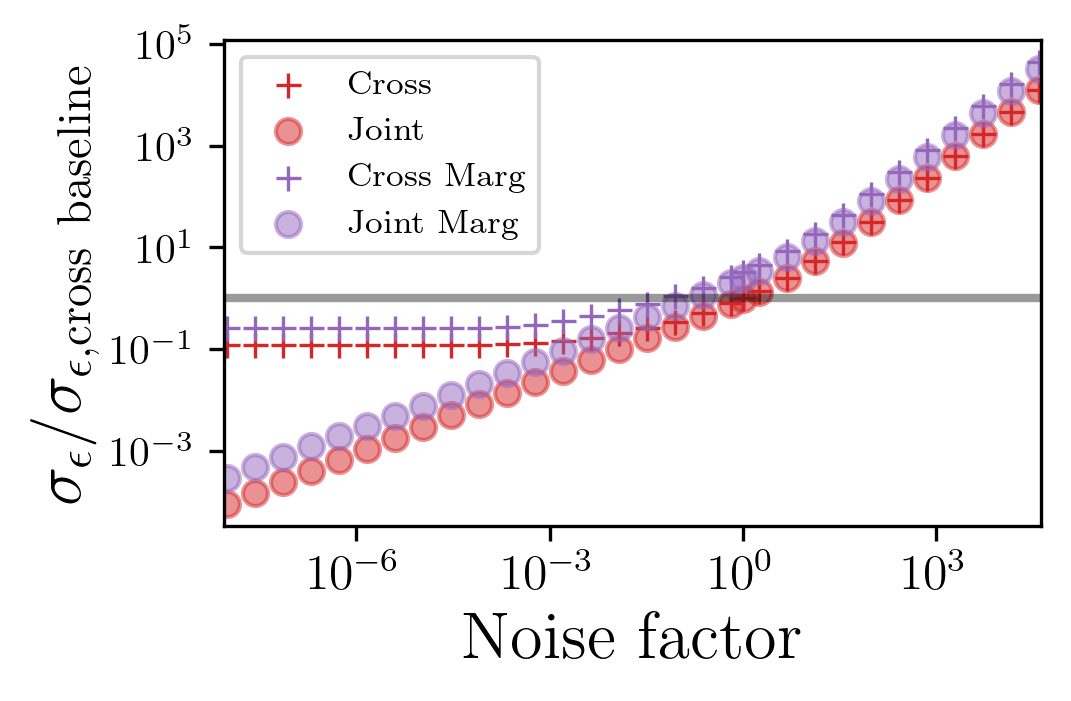

In [27]:
index = 0

from matplotlib.lines import Line2D

fig = plt.figure(figsize=plot.size, dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])


color = lambda i: plot.COLORBLIND_PALETTE_2[i]

ax.hlines(1, factors.min()*(1-0.1), factors.max()*(1+0.1), color = "black", lw = 2, alpha = 0.4)

i = 3
ax.scatter(factors, errors_noise_cross, label = "Cross", color = color(i), marker = "+")
ax.scatter(factors, errors_noise_joint, label = "Joint", color = color(i), alpha = 0.5)

i = 4
ax.scatter(factors, errors_marginalized_noise_cross, label = "Cross Marg", color = color(i), marker = "+")
#ax.scatter(factors, errors_marginalized_noise_cross_extended, label = "Cross Marg Extended", color = color(i), marker = "+")

ax.scatter(factors, errors_marginalized_noise_joint, label = "Joint Marg", color = color(i), alpha = 0.5)



ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel(r'$\sigma_{\epsilon}/\sigma_{\epsilon,\mathrm{cross\ baseline}}$', fontsize=16)
ax.set_xlabel(r'Noise factor', fontsize=16)

ax.set_xlim(factors.min()*(1-0.1), factors.max()*(1+0.1))
ax.legend(fontsize = 8)

plt.subplots_adjust(wspace=0.3)
fig.savefig(f"figures/fisher_varying_noise.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()
plt.show()
plt.close()

# Directly varying number density

In [30]:
import jax.numpy as jnp

import numpy as np

import pathlib


class QEResults:
    def __init__(self, config, sims = False, relative_path = "."):

        name_config = config['name']
        output_config = config['output']
        relative_path = pathlib.Path(relative_path)
        output_dir = relative_path / output_config['directory'] / name_config

        if sims:
            nome = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_normalization_AB.npy"
            nomev = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_variance_AB.npy"
            nometri = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_shot_trispectrum_AB.npy"
            nomebis_mixed = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_cross_shot_AB.npy"
            nomebis = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_shot_bispectrum_AB.npy"
        else:
            nome = f"analysis_theory_normalization_AB.npy"
            nomev = f"analysis_theory_variance_AB.npy"
            nomebis = f"analysis_theory_shot_bispectrum_AB.npy"
            nomebis_mixed = f"analysis_theory_cross_shot_AB.npy"
            nometri = f"analysis_theory_shot_trispectrum_AB.npy"

        self.out_normalization_AB = np.load(output_dir / nome, allow_pickle = True).item() #inverse of normalization N

        self.analysis_cross_shot_AB = np.load(output_dir / nomebis_mixed, allow_pickle = True).item() #cross shot-noise
        self.out_variance_AB = np.load(output_dir / nomev, allow_pickle = True).item() #variance
        self.out_shot_trispectrum = np.load(output_dir / nometri, allow_pickle = True).item() #trispectrum shot noise, assuming all the same
        self.out_shot_bispectrum = np.load(output_dir / nomebis, allow_pickle = True).item() #bispectrum shot noise, assuming all the same


        ps_main_directory = relative_path / config['power_spectrum']['main_directory']
        self.gen_nl_power = np.loadtxt(ps_main_directory/name_config/config['power_spectrum']['nonlinear'])
        self.gen_power = np.loadtxt(ps_main_directory/name_config/config['power_spectrum']['linear'])

        self.pnlinf = lambda kmag: jnp.interp(kmag, self.gen_nl_power[:,0], self.gen_nl_power[:,1])
        self.plinf = lambda kmag: jnp.interp(kmag, self.gen_power[:,0], self.gen_power[:,1])

        kr_config = config['k_range']
        kmin = kr_config['kmin']
        kmax = kr_config['kmax']
        k_samples = kr_config['k_samples']
        k_min_analysis = kr_config['k_min_analysis']
        k_max_analysis = kr_config['k_max_analysis']

        self.kmin = kmin
        self.kmax = kmax
        self.k_min_analysis = k_min_analysis
        self.k_max_analysis = k_max_analysis

        kmin_max = 2*k_min_analysis
        Ks_ = jnp.linspace(k_min_analysis, kmin_max, 20)
        Ks = jnp.logspace(jnp.log10(kmin_max), jnp.log10(k_max_analysis), k_samples)
        Ks = jnp.concatenate([Ks_, Ks])
        self.Ks = jnp.unique(Ks)

    def get_out_normalization_AB(self):
        result = {}
        for key, value in self.out_normalization_AB.items():
            value = np.array(value)
            value[np.abs(value)<1e-10] = 0
            result[key] = jnp.array(value)
        return result

    def get_get_norm(self):
        def get_norm(key):
            N = np.array(self.out_normalization_AB[(key, key)]**-1.)
            N[np.abs(N)>1e10] = 0
            N = jnp.array(N)
            return N
        return get_norm
    
    def get_get_variance(self):
        def get_variance(key):
            N = self.get_get_norm()(key)
            V = self.out_variance_AB[(key, key)]*N**2
            return V
        return get_variance
    
    def get_get_trispectrum(self):
        def get_trispectrum(key):
            N = self.get_get_norm()(key)
            T = self.out_shot_trispectrum[(key, key)]*N**2
            return T
        return get_trispectrum

    def get_get_bispectrum_mixed(self):
        def get_bispectrum_mixed(key):
            N = self.get_get_norm()(key)
            B = self.analysis_cross_shot_AB[(key, key)]*N
            return B
        return get_bispectrum_mixed

    def get_get_bispectrum(self):
        def get_bispectrum(key):
            N = self.get_get_norm()(key)
            B = self.out_shot_bispectrum[(key, key)]*N
            return B
        return get_bispectrum


    def get_get_tot_noises(self):
        def get_tot_noises(key):
            variance = self.get_get_variance()(key)
            bispectrum = self.get_get_bispectrum()(key)
            trispectrum = self.get_get_trispectrum()(key)
            bispectrum_mixed = self.get_get_bispectrum_mixed()(key)
            return variance, bispectrum, trispectrum, bispectrum_mixed

    @staticmethod
    def E_bottaro():
        z_eq = 3400
        a_eq = 1/(1+z_eq)
        a = 1.
        fchi = 1.
        factor = jnp.log(a/a_eq)-181/90
        factor *= fchi
        factor *= 6/5
        return factor

    def get_G(self):
        def G(epsilon, one = 1):
            E = self.E_bottaro()
            return 1+epsilon*E*one
        return G
    


def get_normalization_array(key, keys, Ks, out_normalization_AB):
    jax_out_normalization_AB = np.empty((len(keys), len(Ks)))
    for i, k in enumerate(keys):
        jax_out_normalization_AB[i, :] = out_normalization_AB[(key, k)]
    jax_out_normalization_AB = jnp.array(jax_out_normalization_AB)
    return jax_out_normalization_AB

In [29]:
from copy import deepcopy


selected = [0, 1, 2, 3]#, 4, 5, 6]
Narr = 1

out_results = {}
nbars = []

conf_indices = list(range(1, 32))

conf_vary_kmax_indices = list(range(25, 31))
nbars_kmax = []

conf_ok = []
for i in conf_indices:
    
    configuration_i = f'../../configs/abacus/desi_nbars/config_desi_base_{i}.yaml'

    with open(configuration_i, 'r') as f:
        config_i = yaml.safe_load(f)

    name = config_i["name"]
    path = f"../../results/{name}/"
    #path = f"/users/odarwish/results/desi_base_asymm/"
    
    try:
        QR = QEResults(config_i, relative_path = "../")
    except:
        print(i, "not found")
        continue

    if i not in conf_vary_kmax_indices:
        conf_ok.append(i)
        nbars.append(config_i["number_density"]["nbar_A"])
    else:
        nbars_kmax.append(config_i["number_density"]["nbar_A"])
    
    configuration_base_i = {"mainkey": "n",
                          "QR": QR,
                          "e": 0.,
                          "shot_noise": 1/config_i["number_density"]["nbar_A"], 
                          "variance_factor": 1., 
                          "bispectrum_factor": 0., 
                          "trispectrum_factor": 0., 
                          "asymm_shift": 1., #include asymm shift term or not. If 0, use only G, T asymm
                          "only_asymm_shift": 0., #only include asymm shift term or not, If 1, use only S asymm
                          "growth_eps": 0., #enhanced growth for galaxy clustering
                         }

    F_cross, F_joint = get_full_fisher(**configuration_base_i)
    modes, err_matrix, err_marginalized_matrix = ger_errors(F_joint, selected, k_min_analysis, Kmax, V, Narr = Narr)
    modes, err_matrix_cross, err_marginalized_matrix_cross = ger_errors(F_cross, selected, k_min_analysis, Kmax, V, Narr = Narr)
    out_results[i] = {"modes": modes, "err_matrix": err_matrix, "err_marginalized_matrix": err_marginalized_matrix, "err_matrix_cross": err_matrix_cross, "err_marginalized_matrix_cross": err_marginalized_matrix_cross}
    out_results[i]["F_joint"] = F_joint
    out_results[i]["F_cross"] = F_cross
    

7 not found
8 not found
9 not found


In [30]:
nbars = np.array(nbars)

keys = tuple(['modes', 'err_matrix', 'err_marginalized_matrix', 'err_matrix_cross', 'err_marginalized_matrix_cross'])

index = 0

argmin = np.argmin(abs(nbars-0.0018))
base_nbar_index = conf_ok[argmin]
results = out_results[base_nbar_index]
modes, err_matrix, err_marginalized_matrix, err_matrix_cross, err_marginalized_matrix_cross = [results[k] for k in keys]
base = err_matrix_cross[:, index]

k = 'err_matrix_cross'
errors_noise_cross_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])
k = 'err_marginalized_matrix_cross'
errors_marginalized_noise_cross_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])

k = 'err_matrix'
errors_noise_joint_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])
k = 'err_marginalized_matrix'
errors_marginalized_noise_joint_nbar = np.array([out_results[f][k][:, index]/base for f in conf_ok])

k = 'err_marginalized_matrix'
errors_marginalized_noise_joint_nbar_kmax = np.array([out_results[f][k][:, index]/base for f in conf_vary_kmax_indices])

/tmp/ipykernel_243744/314226828.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


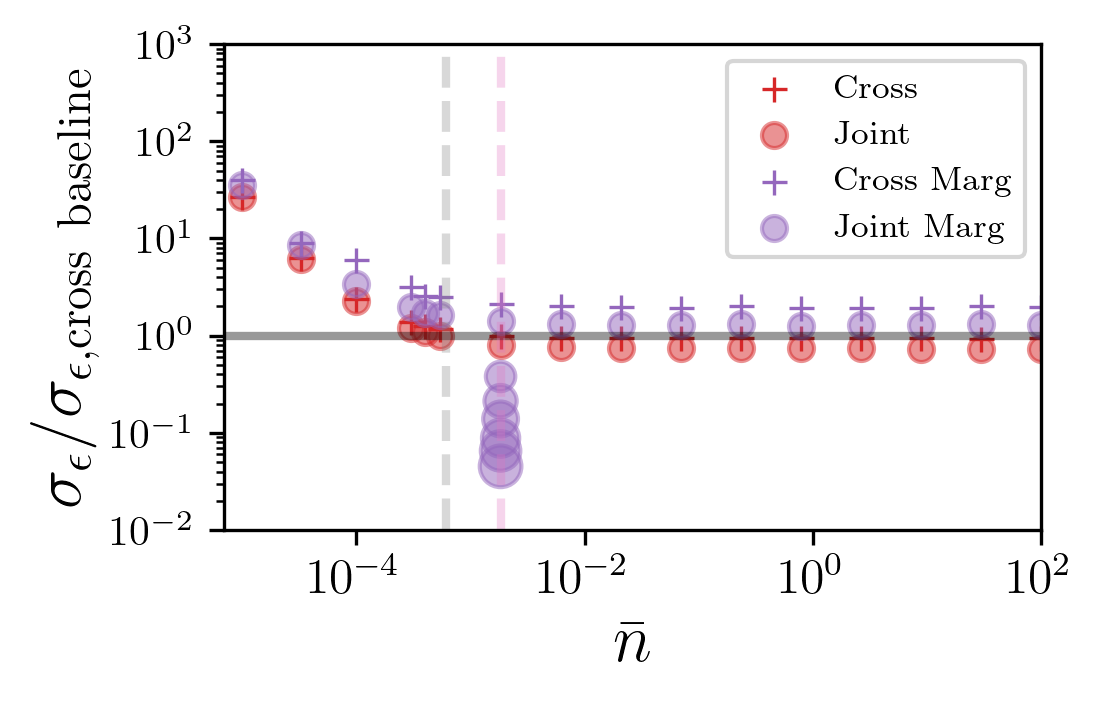

In [31]:
import matplotlib.cm as cm

index = 0

nbar_1 = nbars[argmin] #
nbar_2 = 1e-3 #
nbar_3 = 0.33*nbar_1

from matplotlib.lines import Line2D

fig = plt.figure(figsize=plot.size, dpi=plot.DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = plot.GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])

color = lambda i: plot.COLORBLIND_PALETTE_2[i]


ax.hlines(1, nbars.min()*(1-0.1), nbars.max()*(1+0.1), color = "black", lw = 2, alpha = 0.4)

ax.vlines(nbar_1, 1e-7, 2e3, color = color(6), ls = "--", lw = 2, alpha = 0.3)
#ax.vlines(nbar_2, 1e-7, 2e3, color = color(7), ls = "--", lw = 2, alpha = 0.3)
ax.vlines(nbar_3, 1e-7, 2e3, color = color(7), ls = "--", lw = 2, alpha = 0.3)


i = 3
ax.scatter(nbars, errors_noise_cross_nbar, label = "Cross", color = color(i), marker = "+")
ax.scatter(nbars, errors_noise_joint_nbar, label = "Joint", color = color(i), alpha = 0.5)

i = 4
ax.scatter(nbars, errors_marginalized_noise_cross_nbar, label = "Cross Marg", color = color(i), marker = "+")
ax.scatter(nbars, errors_marginalized_noise_joint_nbar, label = "Joint Marg", color = color(i), alpha = 0.5)


#ax.scatter(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax, label = "Joint Marg Increasing $k_{\mathrm{max,rec}}$", color = color(5), alpha = 0.5)

n_kmax_points = len(nbars_kmax)
colors_kmax = cm.viridis(np.linspace(0.2, 0.8, n_kmax_points))  # or use cm.plasma, cm.coolwarm
#for i, (x, y) in enumerate(zip(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax)):
#    ax.scatter(x, y, color=colors_kmax[i], alpha=0.7)

marker_sizes = np.linspace(50, 100, len(nbars_kmax))  # sizes increase with kmax
ax.scatter(nbars_kmax, errors_marginalized_noise_joint_nbar_kmax, 
           s=marker_sizes, color=color(i), alpha=0.5)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_ylabel(r'$\sigma_{\epsilon}/\sigma_{\epsilon,\mathrm{cross\ baseline}}$', fontsize=14)
ax.set_xlabel(r'$\bar{n}\ h^3\mathrm{[/Mpc^3]}$', fontsize=14)

ax.legend(fontsize = 8)

ax.set_xlim(nbars.min()*(1-0.1), nbars.max()*(1+0.1))
ax.set_xlim(7e-6, 100)
ax.set_ylim(1e-2, 1e3)

plt.subplots_adjust(wspace=0.3)
fig.savefig(f"figures/fisher_varying_nbar.pdf", dpi = 300, bbox_inches='tight')
fig.tight_layout()
plt.show()
plt.close()